# EDA and Preprocessing

**Run:** CPU is sufficient. In Google Colab choose **Runtime → Run all**. The notebook clones the supplied public repo, installs the data dependencies/package, loads revision-pinned GoEmotions simplified splits from Hugging Face, and writes `reports/`, `data/processed/`, and `features/`.

## 1. Reproducible setup

In [10]:
import os, sys, subprocess
from pathlib import Path

HERE = Path.cwd()
if (HERE / 'modules' / 'config.py').exists():
    ROOT = HERE
elif (HERE.parent / 'modules' / 'config.py').exists():
    ROOT = HERE.parent
else:
    ROOT = HERE / 'ML-Assignment-eda'
    if not ROOT.exists():
        subprocess.run(['git', 'clone', 'https://github.com/TCL03-HCMUT/ML-Assignment.git', str(ROOT)], check=True)
        subprocess.run(['git', '-C', str(ROOT), 'checkout', 'de6d795bb7a48aa78a3518701539bd283f51878d'], check=True)
    # Snapshot of the authored data modules: independent of remote publication.
    BUNDLED_SOURCE = {'modules/__init__.py': '"""\nModules for GoEmotions ML Pipeline.\n\nArchitecture:\n    ┌─────────────────────┐     ┌─────────────────────┐\n    │  TraditionalFeature │     │   ModernFeature      │\n    │  Extractor          │     │   Extractor          │\n    │  (BoW, TF-IDF, …)  │     │   (W2V, GloVe, BERT) │\n    └────────┬────────────┘     └────────┬────────────┘\n             │  .npy / .h5               │  .npy / .h5\n             │  (N, D) array             │  (N, D) array\n             └──────────┬────────────────┘\n                        ▼\n               ┌────────────────┐\n               │   Classifier   │  (shared: LogReg, SVM, RF, MLP …)\n               └────────────────┘\n\nSubmodules:\n    config              – Centralized dataclass configs for every pipeline step.\n    data_loader         – Download, load, and explore the GoEmotions dataset.\n    preprocessing       – Configurable text cleaning and normalization.\n    feature_io          – Shared save/load for .npy / .h5 feature arrays.\n    traditional_pipeline – BoW / TF-IDF / n-gram feature extraction.\n    modern_features     – Word2Vec / GloVe / frozen-BERT embedding extraction.\n    classifier          – Shared multi-label classifier for any feature array.\n    dl_pipeline         – End-to-end Transformer fine-tuning (Bonus).\n    evaluation          – Metrics computation and pipeline comparison plots.\n"""\n', 'modules/config.py': '"""\nModule: Configuration\nCentralized configuration for the entire pipeline using Python dataclasses.\nAll configurable options (preprocessing, feature extraction, model selection,\ntraining hyperparameters) are defined here and passed into the pipeline modules.\n"""\n\nfrom dataclasses import dataclass, field\nfrom typing import Optional\n\n\n# ──────────────────────────────────────────────\n#  GoEmotions Label Constants\n# ──────────────────────────────────────────────\n\nLABEL_NAMES = [\n    "admiration", "amusement", "anger", "annoyance", "approval",\n    "caring", "confusion", "curiosity", "desire", "disappointment",\n    "disapproval", "disgust", "embarrassment", "excitement", "fear",\n    "gratitude", "grief", "joy", "love", "nervousness",\n    "optimism", "pride", "realization", "relief", "remorse",\n    "sadness", "surprise", "neutral",\n]\n\nNUM_LABELS = len(LABEL_NAMES)\n\n# Default directory for saving/loading feature arrays\nFEATURES_DIR = "features"\n\n\n# ──────────────────────────────────────────────\n#  Preprocessing Configuration\n# ──────────────────────────────────────────────\n\n@dataclass\nclass PreprocessingConfig:\n    """Controls which preprocessing steps are applied and in what order.\n\n    Implementation Guide:\n    - Each boolean flag toggles a specific preprocessing step.\n    - The `preprocess_dataset` function reads this config and applies only\n      the steps that are set to True, in the order listed below.\n    - This lets you easily compare different preprocessing strategies by\n      creating multiple configs.\n\n    Example usage in notebook:\n        cfg = PreprocessingConfig(lowercase=True, remove_stopwords=True, stemming=True)\n        df_train = preprocess_dataset(df_train, cfg)\n    """\n\n    lowercase: bool = True\n    remove_punctuation: bool = False\n    remove_stopwords: bool = False\n    remove_numbers: bool = False\n    stemming: bool = False          # Use Porter Stemmer\n    lemmatization: bool = False     # Use WordNet Lemmatizer (mutually exclusive with stemming)\n    min_word_length: int = 1        # Drop words shorter than this\n    normalize_unicode: bool = True\n    decode_html: bool = True\n    replace_urls: bool = True\n    replace_users: bool = True\n    preserve_negation: bool = True\n    tokenizer: str = "regex"         # regex | whitespace\n    empty_token: str = "EMPTYTOKEN"\n\n\n# ──────────────────────────────────────────────\n#  Traditional Feature Extraction Configuration\n# ──────────────────────────────────────────────\n\n@dataclass\nclass TraditionalFeatureConfig:\n    """Controls traditional feature extraction (BoW, TF-IDF, n-grams).\n\n    The extractor produces a dense numpy array and saves it to\n    `features_dir` so that the shared `Classifier` can consume it\n    identically to modern embeddings.\n\n    Implementation Guide:\n    - `feature_type`: One of \'bow\', \'tfidf\', \'ngram\'.\n    - `ngram_range`: Tuple for n-gram range, e.g. (1, 1) for unigrams, (1, 2) for uni+bigrams.\n    - `max_features`: Maximum number of features for the vectorizer.\n    - `save_format`: One of \'npy\' or \'h5\'.\n\n    Example usage in notebook:\n        cfg = TraditionalFeatureConfig(feature_type=\'tfidf\', ngram_range=(1, 2))\n        extractor = TraditionalFeatureExtractor(cfg)\n        X_train = extractor.extract_and_save(train_texts, \'tfidf_train\')\n    """\n\n    feature_type: str = "tfidf"          # \'bow\' | \'tfidf\' | \'ngram\'\n    ngram_range: tuple = (1, 1)          # e.g. (1,2) for bigrams\n    max_features: Optional[int] = 10_000\n    save_format: str = "npy"             # \'npy\' | \'h5\'\n    features_dir: str = FEATURES_DIR\n\n\n# ──────────────────────────────────────────────\n#  Modern Feature Extraction Configuration\n# ──────────────────────────────────────────────\n\n@dataclass\nclass ModernFeatureConfig:\n    """Controls neural embedding extraction (Word2Vec, GloVe, frozen BERT).\n\n    The extractor produces a dense numpy array and saves it to\n    `features_dir` so that the shared `Classifier` can consume it\n    identically to traditional features.\n\n    Implementation Guide:\n    - `embedding_type`: One of \'word2vec\', \'glove\', \'bert\'.\n    - `model_name`: HuggingFace model name (only used when embedding_type is \'bert\').\n    - `pooling_strategy`: How to aggregate token embeddings into a single vector.\n        - \'mean\': Average all token embeddings.\n        - \'cls\': Use the [CLS] token output (BERT only).\n    - `save_format`: One of \'npy\' or \'h5\'.\n\n    Example usage in notebook:\n        cfg = ModernFeatureConfig(embedding_type=\'bert\', pooling_strategy=\'cls\')\n        extractor = ModernFeatureExtractor(cfg)\n        X_train = extractor.extract_and_save(train_texts, \'bert_cls_train\')\n    """\n\n    embedding_type: str = "word2vec"          # \'word2vec\' | \'glove\' | \'bert\'\n    model_name: str = "bert-base-uncased"     # HuggingFace model identifier\n    pooling_strategy: str = "mean"            # \'mean\' | \'cls\'\n    save_format: str = "npy"                  # \'npy\' | \'h5\'\n    features_dir: str = FEATURES_DIR\n\n\n# ──────────────────────────────────────────────\n#  Shared Classifier Configuration\n# ──────────────────────────────────────────────\n\n@dataclass\nclass ClassifierConfig:\n    """Controls the classifier that trains on ANY feature array (traditional or modern).\n\n    Both `TraditionalFeatureExtractor` and `ModernFeatureExtractor` produce\n    numpy arrays of shape (N, D).  This single classifier consumes them.\n\n    Implementation Guide:\n    - `classifier_type`: One of \'logistic_regression\', \'svm\', \'random_forest\',\n      \'naive_bayes\', \'mlp\'.\n    - `tuning_method`: One of \'grid\', \'random\', or None to skip tuning.\n\n    Example usage in notebook:\n        # Same classifier, different features\n        clf_cfg = ClassifierConfig(classifier_type=\'svm\', tuning_method=\'grid\')\n\n        clf_trad = Classifier(clf_cfg)\n        clf_trad.train(X_tfidf_train, y_train)\n\n        clf_modern = Classifier(clf_cfg)\n        clf_modern.train(X_bert_train, y_train)\n    """\n\n    classifier_type: str = "logistic_regression"  # \'logistic_regression\' | \'svm\' | \'random_forest\' | \'naive_bayes\' | \'mlp\'\n    tuning_method: Optional[str] = None           # \'grid\' | \'random\' | None\n\n\n# ──────────────────────────────────────────────\n#  Deep Learning Pipeline Configuration\n# ──────────────────────────────────────────────\n\n@dataclass\nclass DLPipelineConfig:\n    """Controls end-to-end deep learning fine-tuning.\n\n    Implementation Guide:\n    - `model_name`: Any HuggingFace model that supports SequenceClassification.\n    - `max_length`: Maximum token length for the tokenizer.\n    - `batch_size`, `epochs`, `learning_rate`: Standard training hyperparameters.\n    - `threshold`: Sigmoid threshold for converting logits to binary predictions.\n\n    Example usage in notebook:\n        cfg = DLPipelineConfig(\n            model_name=\'distilbert-base-uncased\',\n            epochs=5,\n            learning_rate=3e-5,\n            batch_size=32,\n        )\n        pipeline = EndToEndDLPipeline(cfg)\n    """\n\n    model_name: str = "distilbert-base-uncased"\n    max_length: int = 128\n    batch_size: int = 16\n    epochs: int = 3\n    learning_rate: float = 2e-5\n    threshold: float = 0.5\n    num_labels: int = NUM_LABELS\n\n\n# ──────────────────────────────────────────────\n#  Evaluation Configuration\n# ──────────────────────────────────────────────\n\n@dataclass\nclass EvaluationConfig:\n    """Controls evaluation metrics and visualisation options.\n\n    Implementation Guide:\n    - `average_types`: Which F1 averages to compute (e.g. \'micro\', \'macro\', \'weighted\').\n    - `top_n_classes`: Number of classes to show in per-class plots (use None for all 28).\n    - `show_classification_report`: Whether to print sklearn\'s full classification report.\n\n    Example usage in notebook:\n        cfg = EvaluationConfig(top_n_classes=10, show_classification_report=True)\n        metrics = compute_metrics(y_true, y_pred, cfg)\n    """\n\n    average_types: list = field(default_factory=lambda: ["micro", "macro", "weighted"])\n    top_n_classes: Optional[int] = None     # None = show all 28\n    show_classification_report: bool = True\n', 'modules/data_loader.py': '"""Revision-pinned Hugging Face GoEmotions loading and raw-text EDA helpers."""\nfrom pathlib import Path\nimport json\nfrom datasets import load_dataset\nimport numpy as np\nimport pandas as pd\nfrom modules.config import LABEL_NAMES, NUM_LABELS\n\nDATASET_ID = \'google-research-datasets/go_emotions\'\nDATASET_CONFIG = \'simplified\'\n# Commit in the Hugging Face dataset repository, not the Google GitHub repository.\nDATA_REVISION = \'add492243ff905527e67aeb8b80c082af02207c3\'\nEXPECTED_SIZES = {\'train\': 43410, \'validation\': 5426, \'test\': 5427}\n\n\ndef binarize_labels(df, labels_col=\'labels\'):\n    """Preserve label lists and add fixed-order uint8 indicator columns."""\n    from sklearn.preprocessing import MultiLabelBinarizer\n    for row, labels in enumerate(df[labels_col]):\n        if not isinstance(labels, (list, tuple, np.ndarray)) or len(labels) == 0:\n            raise ValueError(f\'Empty or malformed labels at row {row}\')\n        if any(isinstance(i, (bool, np.bool_)) or not isinstance(i, (int, np.integer)) or not 0 <= i < NUM_LABELS for i in labels):\n            raise ValueError(f\'Invalid label ID at row {row}: {labels}\')\n        if len(set(labels)) != len(labels):\n            raise ValueError(f\'Repeated label ID at row {row}\')\n    out = df.copy()\n    y = MultiLabelBinarizer(classes=range(NUM_LABELS)).fit_transform(out[labels_col])\n    out[LABEL_NAMES] = y.astype(np.uint8)\n    return out\n\n\ndef load_goemotions_data(cache_dir=\'data/raw\'):\n    """Load pinned HF simplified splits, preserving official row order and labels.\n\n    ``cache_dir`` holds the Datasets cache and manifest. The Hub library manages\n    its download cache separately (HF_HOME may select its location).\n    Existing GitHub TSV files are not used or deleted. No reshuffling, label\n    selection, imputation or deduplication is performed.\n    """\n    cache = Path(cache_dir)\n    cache.mkdir(parents=True, exist_ok=True)\n    dataset = load_dataset(DATASET_ID, DATASET_CONFIG, revision=DATA_REVISION,\n                           cache_dir=str(cache / \'huggingface\'))\n    if set(dataset) != set(EXPECTED_SIZES):\n        raise ValueError(\'Unexpected dataset splits; expected train/validation/test\')\n    manifest = {\n        \'provider\': \'huggingface\', \'dataset_id\': DATASET_ID,\n        \'config\': DATASET_CONFIG, \'revision\': DATA_REVISION,\n        \'source_url\': f\'https://huggingface.co/datasets/{DATASET_ID}/tree/{DATA_REVISION}\',\n        \'label_names\': LABEL_NAMES,\n        \'splits\': {},\n    }\n    frames = []\n    for split, expected_size in EXPECTED_SIZES.items():\n        source = dataset[split]\n        if source.features[\'labels\'].feature.names != LABEL_NAMES:\n            raise ValueError(f\'Official emotion order disagrees with modules.config in {split}\')\n        df = source.to_pandas()\n        if not {\'id\', \'text\', \'labels\'}.issubset(df.columns):\n            raise ValueError(f\'Missing required columns in {split}\')\n        if len(df) != expected_size:\n            raise ValueError(f\'Unexpected {split} row count: {len(df)}\')\n        if df[\'id\'].isna().any() or df[\'id\'].eq(\'\').any() or df[\'id\'].duplicated().any():\n            raise ValueError(f\'Missing/duplicate comment IDs in {split}\')\n        if df[\'text\'].isna().any() or not df[\'text\'].map(lambda t: isinstance(t, str)).all():\n            raise ValueError(f\'Missing/non-string comments in {split}\')\n        if df[\'text\'].str.strip().eq(\'\').any():\n            raise ValueError(f\'Blank comments in {split}; inspect source before cleaning\')\n        df = binarize_labels(df)\n        df[\'labels\'] = df[\'labels\'].map(lambda values: [int(i) for i in values])\n        manifest[\'splits\'][split] = {\'rows\': len(df)}\n        frames.append(df)\n    (cache / \'manifest.json\').write_text(json.dumps(manifest, indent=2), encoding=\'utf-8\')\n    return tuple(frames)\n\n\ndef get_eda_statistics(df, text_col=\'text\'):\n    """Whitespace-separated word counts and Unicode character counts on RAW text."""\n    counts = df[text_col].str.split().str.len()\n    chars = df[text_col].str.len()\n    nlabels = df[LABEL_NAMES].sum(axis=1)\n    return {\'n_samples\': len(df),\n            \'word_count_stats\': counts.describe(percentiles=[.25,.5,.75,.95,.99]).to_dict(),\n            \'char_count_stats\': chars.describe(percentiles=[.25,.5,.75,.95,.99]).to_dict(),\n            \'label_frequencies\': df[LABEL_NAMES].sum().to_dict(),\n            \'multi_label_ratio\': float((nlabels > 1).mean()),\n            \'label_cardinality\': float(nlabels.mean()),\n            \'label_density\': float(nlabels.mean() / NUM_LABELS)}\n\n\ndef plot_class_distribution(df, label_cols=None):\n    import matplotlib.pyplot as plt\n    counts = df[label_cols or LABEL_NAMES].sum().sort_values()\n    fig, ax = plt.subplots(figsize=(9,8))\n    counts.plot.barh(ax=ax, color=\'#287c9a\')\n    ax.set(title=\'Training label support (labels may overlap)\', xlabel=\'Comments containing label\')\n    fig.tight_layout()\n    return fig\n\n\ndef plot_text_length_distribution(df, text_col=\'text\'):\n    import matplotlib.pyplot as plt\n    fig, axes = plt.subplots(1,2, figsize=(11,4))\n    for ax, values, title in zip(axes, [df[text_col].str.split().str.len(), df[text_col].str.len()], [\'Words (whitespace tokens)\', \'Characters (Unicode code points)\']):\n        ax.hist(values, bins=45, color=\'#287c9a\', alpha=.85)\n        ax.axvline(values.mean(), color=\'#c6682c\', label=f\'Mean {values.mean():.1f}\')\n        ax.axvline(values.median(), color=\'#333333\', linestyle=\'--\', label=f\'Median {values.median():.1f}\')\n        ax.set(xlabel=title, ylabel=\'Comments\', title=f\'Raw training text: {title}\')\n        ax.legend()\n    fig.tight_layout()\n    return fig\n\n\ndef plot_label_cooccurrence(df, label_cols=None):\n    import matplotlib.pyplot as plt\n    import seaborn as sns\n    labels = label_cols or LABEL_NAMES\n    # Cast BEFORE dot product: uint8 would overflow at 255.\n    y = df[labels].to_numpy(dtype=np.int64)\n    co = y.T @ y\n    fig, ax = plt.subplots(figsize=(12,10))\n    sns.heatmap(co, xticklabels=labels, yticklabels=labels, cmap=\'Blues\', ax=ax,\n                mask=np.triu(np.ones_like(co, dtype=bool), k=1))\n    ax.set_title(\'Training label co-occurrence counts (diagonal = support)\')\n    fig.tight_layout()\n    return fig\n', 'modules/preprocessing.py': '"""Configurable, non-destructive text preprocessing for emotion classification."""\nimport html\nimport re\nimport unicodedata\nfrom functools import lru_cache\nfrom modules.config import PreprocessingConfig\n\n# Keep sentiment-bearing negation and intensifiers even during stopword ablation.\nPROTECTED_WORDS = frozenset({\'no\',\'not\',\'nor\',\'never\',\'neither\',\'cannot\',\'very\',\'too\',\'so\',\'more\',\'most\',\'against\'})\nTOKEN_PATTERN = re.compile(r"\\[[A-Za-z_]+\\]|[^\\W_]+(?:[\'’][^\\W_]+)*|[^\\w\\s]", re.UNICODE)\nWORD_PATTERN = re.compile(r"[^\\W_]+(?:[\'’][^\\W_]+)*", re.UNICODE)\n\n\ndef lowercase(text):\n    return text.lower()\n\n\ndef remove_punctuation(text):\n    """Replace punctuation by spaces; keep apostrophes, emoji and symbol cues."""\n    return \'\'.join(\' \' if unicodedata.category(c).startswith(\'P\') and c not in "\'’" else c for c in text)\n\n\ndef remove_numbers(text):\n    return re.sub(r\'\\d+\', \' \', text)\n\n\ndef remove_extra_whitespace(text):\n    return re.sub(r\'\\s+\', \' \', text).strip()\n\n\ndef remove_stopwords(text, stop_words):\n    # Tokenize punctuation separately so \'the!\' and \'the\' are treated consistently.\n    return \' \'.join(t for t in tokenize_text(text) if t.lower() not in stop_words)\n\n\ndef tokenize_text(text, method=\'regex\'):\n    if method == \'whitespace\':\n        return text.split()\n    if method == \'regex\':\n        return TOKEN_PATTERN.findall(text)\n    raise ValueError("tokenizer must be \'regex\' or \'whitespace\'")\n\n\ndef word_tokens(text):\n    """Lexical tokens for EDA; emoji and punctuation are analyzed separately."""\n    return WORD_PATTERN.findall(text.lower())\n\n\n@lru_cache(maxsize=1)\ndef default_stopwords():\n    from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS\n    return frozenset(ENGLISH_STOP_WORDS) - PROTECTED_WORDS\n\n\ndef prepare_nltk_resources(config):\n    """Explicitly prepare optional WordNet; defaults need no NLTK downloads."""\n    if config.lemmatization:\n        import nltk\n        import os\n        from pathlib import Path\n        resource_dir = Path(os.environ.get(\'NLTK_DATA\', \'.cache/nltk_data\')).resolve()\n        resource_dir.mkdir(parents=True, exist_ok=True)\n        if str(resource_dir) not in nltk.data.path:\n            nltk.data.path.insert(0, str(resource_dir))\n        try:\n            nltk.corpus.wordnet.ensure_loaded()\n        except LookupError:\n            if not nltk.download(\'wordnet\', download_dir=str(resource_dir), quiet=True):\n                raise RuntimeError(\'Cannot download WordNet for requested lemmatization\')\n\n\ndef apply_stemming(text):\n    from nltk.stem import PorterStemmer\n    stemmer = PorterStemmer()\n    return \' \'.join(stemmer.stem(t) if t.isalpha() else t for t in tokenize_text(text))\n\n\ndef apply_lemmatization(text):\n    from nltk.stem import WordNetLemmatizer\n    lemmatizer = WordNetLemmatizer()\n    # Noun-only WordNet normalization; no claim of POS-aware lemmatization.\n    return \' \'.join(lemmatizer.lemmatize(t) if t.isalpha() else t for t in tokenize_text(text))\n\n\ndef filter_short_words(text, min_length):\n    return \' \'.join(t for t in tokenize_text(text) if not t.isalpha() or len(t) >= min_length)\n\n\ndef preprocess_text(text, config: PreprocessingConfig, stop_words=None):\n    if not isinstance(text, str):\n        raise TypeError(\'Text must be a string; audit missing values before preprocessing\')\n    if config.stemming and config.lemmatization:\n        raise ValueError(\'Choose stemming or lemmatization, not both\')\n    if config.tokenizer not in {\'regex\', \'whitespace\'}:\n        raise ValueError(\'Unsupported tokenizer\')\n    if not isinstance(config.empty_token, str) or not config.empty_token.strip():\n        raise ValueError(\'empty_token must be a nonblank string\')\n    if config.min_word_length < 1:\n        raise ValueError(\'min_word_length must be positive\')\n    text = unicodedata.normalize(\'NFC\', text) if config.normalize_unicode else text\n    text = html.unescape(text) if config.decode_html else text\n    if config.replace_urls:\n        text = re.sub(r\'https?://\\S+|www\\.\\S+\', \' URLTOKEN \', text, flags=re.I)\n    if config.replace_users:\n        text = re.sub(r\'(?<!\\w)(?:/?u/|@)[\\w-]+\', \' USERTOKEN \', text)\n    if config.lowercase:\n        text = lowercase(text)\n    if config.remove_punctuation:\n        text = remove_punctuation(text)\n    if config.remove_numbers:\n        text = remove_numbers(text)\n    text = remove_extra_whitespace(text)\n    if config.remove_stopwords:\n        stops = set(default_stopwords() if stop_words is None else stop_words)\n        if stop_words is None and not config.preserve_negation:\n            from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS\n            stops = set(ENGLISH_STOP_WORDS)\n        if config.preserve_negation:\n            stops -= PROTECTED_WORDS\n        text = remove_stopwords(text, stops)\n    if config.stemming:\n        text = apply_stemming(text)\n    elif config.lemmatization:\n        text = apply_lemmatization(text)\n    if config.min_word_length > 1:\n        text = filter_short_words(text, config.min_word_length)\n    # Keep empty transformations as an explicit feature; preserve row/label alignment.\n    return remove_extra_whitespace(text) or config.empty_token\n\n\ndef preprocess_dataset(df, config: PreprocessingConfig, text_col=\'text\'):\n    prepare_nltk_resources(config)\n    out = df.copy()\n    out[\'processed_text\'] = out[text_col].map(lambda t: preprocess_text(t, config))\n    out[\'tokens\'] = out[\'processed_text\'].map(lambda t: tokenize_text(t, config.tokenizer))\n    return out\n', 'modules/eda.py': '"""Training-only content EDA, split quality audits, and report-ready artifacts."""\nfrom collections import Counter\nfrom itertools import combinations\nfrom pathlib import Path\nimport json\nimport re\nimport numpy as np\nimport pandas as pd\nfrom modules.config import LABEL_NAMES\nfrom modules.data_loader import get_eda_statistics, plot_class_distribution, plot_text_length_distribution, plot_label_cooccurrence\nfrom modules.preprocessing import default_stopwords, word_tokens, remove_extra_whitespace\n\n\ndef normalized_key(text):\n    # Conservative diagnostic key, NOT a model preprocessing operation.\n    return remove_extra_whitespace(text).casefold() if isinstance(text, str) else None\n\n\ndef audit_splits(splits):\n    rows, overlaps = [], []\n    for name, df in splits.items():\n        keys = df.text.map(normalized_key)\n        labelsets = df.labels.map(lambda x: tuple(sorted(x)))\n        conflicts = pd.DataFrame({\'key\':keys,\'labels\':labelsets}).groupby(\'key\').labels.nunique()\n        rows.append({\'split\':name, \'rows\':len(df), \'missing_text\':int(df.text.isna().sum()),\n            \'blank_text\':int(df.text.str.strip().eq(\'\').sum()),\n            \'missing_id\':int(df.id.isna().sum() + df.id.eq(\'\').sum()),\n            \'duplicate_ids\':int(df.id.duplicated().sum()),\n            \'exact_duplicate_excess\':int(df.text.duplicated().sum()),\n            \'normalized_duplicate_excess\':int(keys.duplicated().sum()),\n            \'conflicting_text_groups\':int((conflicts>1).sum())})\n    for a,b in combinations(splits,2):\n        ka = splits[a].text.map(normalized_key)\n        kb = splits[b].text.map(normalized_key)\n        shared = set(ka) & set(kb)\n        overlaps.append({\'split_a\':a,\'split_b\':b,\n            \'shared_ids\':len(set(splits[a].id)&set(splits[b].id)),\n            \'shared_exact_texts\':len(set(splits[a].text)&set(splits[b].text)),\n            \'shared_normalized_texts\':len(shared),\n            \'affected_rows_a\':int(ka.isin(shared).sum()), \'affected_rows_b\':int(kb.isin(shared).sum())})\n    return pd.DataFrame(rows), pd.DataFrame(overlaps)\n\n\ndef run_eda(splits, output_dir=\'reports\'):\n    import matplotlib.pyplot as plt\n    from sklearn.feature_extraction.text import TfidfVectorizer\n    from sklearn.metrics.pairwise import cosine_similarity\n    out = Path(output_dir)\n    tables = out/\'tables\'; figures = out/\'figures\'\n    tables.mkdir(parents=True,exist_ok=True); figures.mkdir(parents=True,exist_ok=True)\n    train = splits[\'train\']\n    stats = {name:get_eda_statistics(df) for name,df in splits.items()}\n    (out/\'eda_statistics.json\').write_text(json.dumps(stats,indent=2))\n    quality, overlap = audit_splits(splits)\n    quality.to_csv(tables/\'quality_audit.csv\',index=False)\n    overlap.to_csv(tables/\'split_overlap.csv\',index=False)\n    length_rows=[]\n    for split,s in stats.items():\n        for unit in (\'word\',\'char\'):\n            length_rows.append({\'split\':split,\'unit\':unit,**s[f\'{unit}_count_stats\']})\n    pd.DataFrame(length_rows).to_csv(tables/\'length_statistics.csv\',index=False)\n    supports = pd.DataFrame({name:df[LABEL_NAMES].sum() for name,df in splits.items()})\n    prevalence = pd.DataFrame({name:df[LABEL_NAMES].mean() for name,df in splits.items()})\n    supports.to_csv(tables/\'label_support.csv\',index_label=\'emotion\')\n    prevalence.to_csv(tables/\'label_prevalence.csv\',index_label=\'emotion\')\n    drift = prevalence.sub(prevalence[\'train\'],axis=0)*100\n    drift.to_csv(tables/\'label_prevalence_drift_pp.csv\',index_label=\'emotion\')\n    # Label support sums exceed N because each comment may have multiple labels.\n    y = train[LABEL_NAMES].to_numpy(dtype=np.int64)\n    cardinality = y.sum(axis=1)\n    pd.Series(cardinality).value_counts().sort_index().to_csv(tables/\'labels_per_comment.csv\',index_label=\'label_count\')\n    co = y.T@y\n    pd.DataFrame(co,index=LABEL_NAMES,columns=LABEL_NAMES).to_csv(tables/\'cooccurrence.csv\',index_label=\'emotion\')\n    pairs = []\n    for i,j in combinations(range(len(LABEL_NAMES)),2):\n        union = co[i,i]+co[j,j]-co[i,j]\n        pairs.append({\'emotion_a\':LABEL_NAMES[i],\'emotion_b\':LABEL_NAMES[j],\n                      \'count\':int(co[i,j]),\'jaccard\':float(co[i,j]/union) if union else 0})\n    pd.DataFrame(pairs).sort_values(\'count\',ascending=False).to_csv(tables/\'emotion_pairs.csv\',index=False)\n    stops = default_stopwords()\n    raw_tokens = train.text.map(word_tokens)\n    content = raw_tokens.map(lambda tokens:[t for t in tokens if t not in stops and t not in {\'name\',\'religion\'}])\n    all_tokens = Counter(t for tokens in raw_tokens for t in tokens)\n    content_tokens = Counter(t for tokens in content for t in tokens)\n    stopcounts = Counter({t:n for t,n in all_tokens.items() if t in stops})\n    for name, counter in [(\'raw_word_frequencies\',all_tokens),(\'content_word_frequencies\',content_tokens),(\'stopword_frequencies\',stopcounts)]:\n        pd.DataFrame(counter.most_common(),columns=[\'term\',\'count\']).to_csv(tables/f\'{name}.csv\',index=False)\n    # Adjacent bigrams are constructed BEFORE filtering: no invented phrases across removed words.\n    bigrams = Counter(\' \'.join((a,b)) for tokens in raw_tokens for a,b in zip(tokens,tokens[1:])\n                      if a not in stops and b not in stops and a not in {\'name\',\'religion\'} and b not in {\'name\',\'religion\'})\n    pd.DataFrame(bigrams.most_common(100),columns=[\'bigram\',\'count\']).to_csv(tables/\'adjacent_bigrams.csv\',index=False)\n    category_rows, vocabulary_rows=[] , []\n    for i,label in enumerate(LABEL_NAMES):\n        selected = content[y[:,i]==1]\n        counter = Counter(t for row in selected for t in row)\n        category_rows.extend({\'emotion\':label,\'term\':t,\'count\':n} for t,n in counter.most_common(50))\n        total = sum(counter.values())\n        vocabulary_rows.append({\'emotion\':label,\'comments\':int(y[:,i].sum()),\'content_tokens\':total,\n              \'unique_tokens\':len(counter),\'type_token_ratio\':len(counter)/total if total else 0,\n              \'mean_raw_words\':float(train.loc[y[:,i]==1,\'text\'].str.split().str.len().mean())})\n    pd.DataFrame(category_rows).to_csv(tables/\'top_words_by_emotion.csv\',index=False)\n    pd.DataFrame(vocabulary_rows).to_csv(tables/\'vocabulary_by_emotion.csv\',index=False)\n    # Training only; per-class mean TF-IDF and centroid similarity, not classifier results.\n    vectorizer = TfidfVectorizer(tokenizer=word_tokens,token_pattern=None,lowercase=False,\n        stop_words=sorted(stops | {\'name\',\'religion\'}),min_df=3,max_features=15000)\n    x = vectorizer.fit_transform(train.text)\n    features = vectorizer.get_feature_names_out()\n    centroids = np.vstack([np.asarray(x[y[:,i]==1].mean(axis=0)).ravel() for i in range(len(LABEL_NAMES))])\n    terms=[]\n    for i,label in enumerate(LABEL_NAMES):\n        terms.extend({\'emotion\':label,\'term\':features[j],\'mean_tfidf\':float(centroids[i,j])}\n                     for j in np.argsort(centroids[i])[-15:][::-1])\n    pd.DataFrame(terms).to_csv(tables/\'top_tfidf_by_emotion.csv\',index=False)\n    similarity=cosine_similarity(centroids)\n    pd.DataFrame(similarity,index=LABEL_NAMES,columns=LABEL_NAMES).to_csv(tables/\'centroid_similarity.csv\',index_label=\'emotion\')\n    train_lengths=train.text.str.split().str.len()\n    q1,q3=train_lengths.quantile([.25,.75]); threshold=q3+1.5*(q3-q1)\n    long_rows=train.loc[train_lengths>threshold,[\'id\',\'text\',\'labels\']].copy()\n    long_rows[\'word_count\']=train_lengths[train_lengths>threshold]\n    long_rows.sort_values(\'word_count\',ascending=False).to_csv(tables/\'long_comment_review.csv\',index=False)\n    # IQR flag is a review aid; valid long comments are NOT deleted.\n    flags = {\'url\':r\'https?://|www\\.\', \'user_mention\':r\'(?:/?u/|@)[\\w-]+\',\n             \'masked_entity\':r\'\\[(?:NAME|RELIGION)\\]\', \'negation\':r"\\b(?:no|not|never|cannot)\\b|n[\'’]t\\b",\n             \'exclamation\':r\'!\', \'question\':r\'\\?\', \'non_ascii\':r\'[^\\x00-\\x7F]\'}\n    cues = pd.DataFrame([{\'cue\':k,\'comments\':int(train.text.str.contains(v,flags=re.I,regex=True).sum())} for k,v in flags.items()])\n    cues[\'percent\']=cues.comments/len(train)*100\n    cues.to_csv(tables/\'text_cues.csv\',index=False)\n    samples=[]\n    for label in LABEL_NAMES:\n        for _, row in train.loc[train[label]==1].head(2).iterrows():\n            samples.append({\'emotion\':label,\'id\':row.id,\'text\':row.text,\'labels\':row.labels})\n    pd.DataFrame(samples).to_csv(tables/\'samples_by_emotion.csv\',index=False)\n    def save(fig,name):\n        fig.savefig(figures/f\'{name}.png\',dpi=150,bbox_inches=\'tight\');plt.close(fig)\n    save(plot_class_distribution(train),\'label_support\')\n    save(plot_text_length_distribution(train),\'text_lengths\')\n    save(plot_label_cooccurrence(train),\'cooccurrence\')\n    fig,ax=plt.subplots(figsize=(8,4));pd.Series(cardinality).value_counts().sort_index().plot.bar(ax=ax,color=\'#287c9a\')\n    ax.set(title=\'Training labels per comment\',xlabel=\'Number of labels\',ylabel=\'Comments\');fig.tight_layout();save(fig,\'label_cardinality\')\n    fig,axes=plt.subplots(1,2,figsize=(12,6))\n    for ax,counter,title in zip(axes,[content_tokens,bigrams],[\'Top content words\',\'Top adjacent content bigrams\']):\n        items=counter.most_common(20)[::-1]\n        ax.barh([t for t,n in items],[n for t,n in items],color=\'#287c9a\');ax.set(title=title,xlabel=\'Training occurrences\')\n    fig.tight_layout();save(fig,\'word_frequencies\')\n    fig,ax=plt.subplots(figsize=(12,10))\n    import seaborn as sns\n    sns.heatmap(similarity,xticklabels=LABEL_NAMES,yticklabels=LABEL_NAMES,cmap=\'viridis\',vmin=0,vmax=1,ax=ax)\n    ax.set_title(\'Cosine similarity of TRAINING mean TF-IDF centroids\');fig.tight_layout();save(fig,\'centroid_similarity\')\n    fig,ax=plt.subplots(figsize=(9,7));prevalence.mul(100).plot.barh(ax=ax)\n    ax.set(title=\'Label prevalence by official split\',xlabel=\'Percentage of comments\');fig.tight_layout();save(fig,\'split_prevalence\')\n    summary={\'train_word_tokens\':sum(all_tokens.values()),\'train_lexical_vocabulary\':len(all_tokens),\n        \'content_vocabulary\':len(content_tokens),\'stopword_token_fraction\':sum(stopcounts.values())/sum(all_tokens.values()),\n        \'iqr_upper_word_threshold\':float(threshold),\'long_comment_flags\':len(long_rows),\n        \'max_label_prevalence_drift_pp\':float(drift[[\'validation\',\'test\']].abs().to_numpy().max())}\n    (out/\'content_summary.json\').write_text(json.dumps(summary,indent=2))\n    return {\'statistics\':stats,\'quality\':quality,\'overlap\':overlap,\'content_summary\':summary,\'supports\':supports}\n', 'modules/data_preparation.py': '"""Export row-aligned preprocessed text and labels for downstream models."""\nfrom dataclasses import asdict\nfrom pathlib import Path\nimport json\nimport numpy as np\nimport pandas as pd\nfrom modules.config import LABEL_NAMES, PreprocessingConfig\nfrom modules.preprocessing import preprocess_dataset\n\n\ndef prepare_splits(splits, config=None, data_dir=\'data/processed\', features_dir=\'features\'):\n    config = config or PreprocessingConfig()\n    processed = {name: preprocess_dataset(df, config) for name, df in splits.items()}\n    data_dir = Path(data_dir)\n    features_dir = Path(features_dir)\n    data_dir.mkdir(parents=True, exist_ok=True)\n    features_dir.mkdir(parents=True, exist_ok=True)\n    impact = []\n    for name, df in processed.items():\n        df[[\'id\', \'text\', \'processed_text\', \'tokens\', \'labels\']].to_json(\n            data_dir / f\'{name}.jsonl\', orient=\'records\', lines=True, force_ascii=False)\n        y = df[LABEL_NAMES].to_numpy(dtype=np.uint8)\n        np.save(features_dir / f\'{name}_labels.npy\', y, allow_pickle=False)\n        impact.append({\n            \'split\': name, \'rows\': len(df),\n            \'mean_tokens\': float(df.tokens.map(len).mean()),\n            \'empty_fallback_rows\': int(df.processed_text.eq(config.empty_token).sum()),\n        })\n        assert len(df) == len(splits[name]) and df.id.equals(splits[name].id)\n        assert np.array_equal(y, splits[name][LABEL_NAMES].to_numpy())\n    metadata = {\n        \'label_names\': LABEL_NAMES, \'config\': asdict(config),\n        \'split_policy\': \'official; repeated text retained and audited\',\n        \'impact\': impact,\n        \'artifacts_are\': \'raw/processed text, tokens and multi-hot labels; model tokenization/padding handled downstream\',\n    }\n    (features_dir / \'preprocessing_metadata.json\').write_text(json.dumps(metadata, indent=2))\n    return processed, pd.DataFrame(impact), metadata\n\n\ndef compare_preprocessing(train):\n    """Data-impact comparison only; no model-quality claims without classifiers."""\n    profiles={\'emotion_preserving\':PreprocessingConfig(),\n              \'stopwords_ablation\':PreprocessingConfig(remove_stopwords=True),\n              \'punctuation_ablation\':PreprocessingConfig(remove_punctuation=True),\n              \'embedding_minimal\':PreprocessingConfig(lowercase=False,replace_urls=False,replace_users=False)}\n    rows=[]\n    for name,config in profiles.items():\n        df=preprocess_dataset(train,config)\n        rows.append({\'profile\':name,\'mean_tokens\':float(df.tokens.map(len).mean()),\n            \'vocabulary\':len({t for tokens in df.tokens for t in tokens}),\n            \'changed_comments\':int(df.processed_text.ne(df.text).sum()),\n            \'empty_fallback_rows\':int(df.processed_text.eq(config.empty_token).sum())})\n    return pd.DataFrame(rows)\n', 'modules/eda_report.py': '"""Generate an editable Markdown EDA/preprocessing report from computed tables."""\nfrom pathlib import Path\nimport json\nimport pandas as pd\n\n\ndef write_report(report_dir=\'reports\'):\n    """Write and return the Markdown report; final submission PDF is prepared separately."""\n    out = Path(report_dir)\n    stats = json.loads((out/\'eda_statistics.json\').read_text())\n    content = json.loads((out/\'content_summary.json\').read_text())\n    quality = pd.read_csv(out/\'tables/quality_audit.csv\')\n    overlap = pd.read_csv(out/\'tables/split_overlap.csv\')\n    support = pd.read_csv(out/\'tables/label_support.csv\').set_index(\'emotion\')\n    train = stats[\'train\']; w = train[\'word_count_stats\']; c = train[\'char_count_stats\']\n    largest = support.train.idxmax(); smallest = support.train.idxmin()\n    pairs = pd.read_csv(out/\'tables/emotion_pairs.csv\').iloc[0]\n    freq = pd.read_csv(out/\'tables/content_word_frequencies.csv\').head(10)\n    profiles = pd.read_csv(out/\'tables/preprocessing_comparison.csv\')\n    impact = pd.read_csv(out/\'tables/preprocessing_impact.csv\')\n    md = [\'# GoEmotions: EDA and Preprocessing\\n\']\n\n    def title(text):\n        md.append(\'\\n## \'+text+\'\\n\')\n\n    def para(text):\n        md.append(text+\'\\n\')\n\n    def table(headers, rows):\n        def cell(value):\n            return str(value).replace(\'|\', \'\\\\|\').replace(\'\\n\', \' \')\n        md.append(\'| \'+\' | \'.join(cell(x) for x in headers)+\' |\\n\'\n                  \'| \'+\' | \'.join([\'---\']*len(headers))+\' |\\n\'\n                  +\'\\n\'.join(\'| \'+\' | \'.join(cell(x) for x in row)+\' |\' for row in rows)+\'\\n\')\n\n    def figure(name, caption):\n        para(caption)\n        md.append(f\'![{caption}](figures/{name}.png)\\n\')\n\n    para(\'Machine Learning - Task 2 | Semester I, Academic Year 2026-2027. This report covers the data and foundation work. Model experiments and modern embedding extraction remain separate assignment deliverables.\')\n    title(\'1. Requirements and data provenance\')\n    para(\'The assignment requires raw word-count statistics, text-length distributions, word frequencies, configurable preprocessing, a public-data Colab notebook, and saved features for the eventual traditional/modern comparison. Missing-value and categorical constraints for Task 1 do not apply to Task 2. Dataset uniqueness and instructor acceptance must be confirmed by the group.\')\n    para(\'We use the agreement-filtered simplified GoEmotions splits, loaded from Hugging Face google-research-datasets/go_emotions at dataset revision add492243ff905527e67aeb8b80c082af02207c3. The manifest in data/raw/manifest.json records the source, dataset revision, label order and row counts. The loader checks split names, schema, IDs, text and labels without requiring custom content hashes. The source was verified against official TSV records with standard quote decoding during migration; the earlier QUOTE_NONE loader retained TSV quote escapes. The dataset has 27 emotions plus neutral. Targets are multi-label: one comment may have several emotions. Raw annotator-level CSV rows are not independent comments and are not used here.\')\n    table([\'Split\',\'Comments\',\'Purpose\'],[[\'Train\',43410,\'Content EDA and fitting\'],[\'Validation\',5426,\'Later model/configuration selection\'],[\'Test\',5427,\'Final model evaluation; quality audit only\']])\n    para(\'Following the lecturer example, size statistics use untouched raw text, while keyword analyses use lexical tokens with stopwords filtered. All word frequencies, emotion keywords, TF-IDF centroids, and configuration-impact comparisons are computed on training data only. Held-out labels are summarized for a predeclared quality audit, not used to tune models.\')\n    title(\'2. Data quality and split integrity\')\n    table([\'Split\',\'Missing text\',\'Blank text\',\'Repeated text*\',\'Conflicting groups\'],[[r.split,r.missing_text,r.blank_text,r.normalized_duplicate_excess,r.conflicting_text_groups] for r in quality.itertuples()])\n    para(\'*Repeated text is excess rows sharing a case-folded, whitespace-normalized key. Distinct comment IDs may contain the same short phrase with different contextual annotations. They are not silently merged or relabeled. Invalid labels and blank comments are rejected by the loader; missing emotion targets must never be imputed as neutral.\')\n    table([\'Split pair\',\'Shared IDs\',\'Shared normalized texts\',\'Affected later rows\'],[[f\'{r.split_a} / {r.split_b}\',r.shared_ids,r.shared_normalized_texts,r.affected_rows_b] for r in overlap.itertuples()])\n    para(\'The default preserves official benchmark rows and reports overlap as a possible source of optimistic evaluation. Duplicate text is audited without deleting rows. Any later change to the official split policy must be documented and use identical data rows across compared classifiers.\')\n    para(f\'An IQR rule flags {content["long_comment_flags"]:,} training comments above {content["iqr_upper_word_threshold"]:.1f} whitespace words for inspection. Long texts are valid observations, so no automatic outlier deletion is applied. Review examples are exported to tables/long_comment_review.csv.\')\n    title(\'3. Raw text size and distribution\')\n    table([\'Measure\',\'Words\',\'Characters\'],[[key,f\'{w[key]:.2f}\',f\'{c[key]:.2f}\'] for key in [\'mean\',\'std\',\'min\',\'25%\',\'50%\',\'75%\',\'95%\',\'99%\',\'max\']])\n    para(\'A word here is a whitespace-separated raw token; a character is a Unicode code point, including spaces and punctuation. Keyword tokens use a separate regex that retains internal apostrophes. These counts are neither pretrained subword lengths nor directly comparable to the original source model sequence-length setting.\')\n    figure(\'text_lengths\',\'Figure 1. Raw training word and character distributions.\')\n    para(f\'The training median is {w["50%"]:.0f} words versus a mean of {w["mean"]:.2f}; the maximum is {w["max"]:.0f}. Sequence length should be chosen from the training distribution and truncation quantified on every split. Punctuation, capitalization and Unicode symbols can express emotion and should be preserved or studied through controlled ablations.\')\n    title(\'4. Label imbalance and multi-label structure\')\n    para(f\'Training contains {train["multi_label_ratio"]*100:.2f}% multi-label comments. Mean label cardinality is {train["label_cardinality"]:.3f}; density is {train["label_density"]:.4f}. The largest class is {largest} ({support.loc[largest,"train"]:,} positives) and the smallest is {smallest} ({support.loc[smallest,"train"]:,}), a {support.loc[largest,"train"]/support.loc[smallest,"train"]:.1f}:1 support ratio. Prevalence percentages use comments as denominator and can sum above 100%.\')\n    figure(\'label_support\',\'Figure 2. Positive comments for each training label.\')\n    para(\'Preserve all labels as a fixed-order 28-column multi-hot matrix, including neutral. Selecting only the first label would change the learning task. Use one-vs-rest traditional classifiers and micro/macro/per-label F1, with validation-only threshold selection. Subset accuracy is strict; majority/neutral predictions alone conceal rare-label failures. Resampling and class weighting, if tried, belong to training only.\')\n    title(\'5. Emotion relationships and split prevalence\')\n    para(f\'The largest off-diagonal co-occurrence is {pairs.emotion_a} + {pairs.emotion_b}: {pairs["count"]:,} training comments, Jaccard {pairs.jaccard:.3f}. Co-occurrence counts and Jaccard scores are both exported. Large support can drive large raw counts; these are associations, not causal relationships.\')\n    figure(\'cooccurrence\',\'Figure 3. Label co-occurrence; diagonal entries are class support.\')\n    para(f\'The maximum absolute held-out versus training label-prevalence difference is {content["max_label_prevalence_drift_pp"]:.2f} percentage points. Split-level support/prevalence tables and a plot are exported for audit. Rare labels have limited validation/test support; report their uncertainty rather than interpreting small differences as decisive.\')\n    title(\'6. Word frequencies, vocabulary and class keywords\')\n    para(f\'Training has {content["train_word_tokens"]:,} lexical token occurrences and {content["train_lexical_vocabulary"]:,} unique lexical forms. The filtered content vocabulary has {content["content_vocabulary"]:,} forms. The configured stopword list accounts for {content["stopword_token_fraction"]*100:.2f}% of lexical occurrences. Negations and intensifiers are protected. NAME and RELIGION mask tokens are excluded from keyword tables only, not erased from model input.\')\n    para(\'The top content words are \'+\', \'.join(f\'{r.term} ({r.count})\' for r in freq.itertuples())+\'. Frequency indicates corpus usage, not guaranteed predictive value.\')\n    figure(\'word_frequencies\',\'Figure 4. Content words and adjacent lexical bigrams.\')\n    para(\'The report tables include top 50 words per emotion, vocabulary size and type-token ratio, mean raw word counts per emotion, top mean TF-IDF terms, stopword counts, and example comments for all 28 labels. A multi-label comment contributes to each of its categories. Type-token ratio depends on sample size and should not be read as an unbiased ranking of emotional complexity. Bigrams are formed before filtering so removed words do not create false adjacency.\')\n    para(\'Cosine similarity of mean training TF-IDF centroids is exported with a heatmap. It measures lexical overlap, not classification accuracy or the lecturer example\\\'s mean pairwise document similarity. Shared multi-label comments can increase overlap. No universal similarity threshold establishes that two emotions are easy or hard to distinguish.\')\n    title(\'7. Configurable preprocessing and data handoff\')\n    para(\'Default steps: NFC Unicode normalization, HTML entity decoding, URL/user placeholders, lowercasing, and whitespace normalization. Preserve raw text, punctuation, emoji, apostrophes, negation, masked entities, and all labels. Missing values raise an error; a valid comment emptied by an aggressive transformation receives an explicit EMPTYTOKEN. Stemming and noun-only WordNet lemmatization are optional and mutually exclusive; neither is enabled by default.\')\n    table([\'Training profile\',\'Mean tokens\',\'Vocabulary\',\'Empty fallback\'],[[r.profile,f\'{r.mean_tokens:.2f}\',r.vocabulary,r.empty_fallback_rows] for r in profiles.itertuples()])\n    para(\'These are executed preprocessing-impact configurations, not predictive-performance experiments. Removing stopwords can remove emotional style; punctuation ablation can remove emphasis. Use validation model metrics later to compare their benefit. Pretrained embedding tokenizers should receive original/minimally normalized text and perform their own tokenization, padding and truncation.\')\n    table([\'Split\',\'Comments\',\'Mean tokens\',\'Empty fallback\'],[[r.split,r.rows,f\'{r.mean_tokens:.2f}\',r.empty_fallback_rows] for r in impact.itertuples()])\n    para(\'Exports include original text, processed text, readable token lists, comment IDs and multi-hot labels, preserving row order. No custom numeric vocabulary, padding or truncation is performed in the EDA/preprocessing handoff. Downstream model code must configure padding/truncation with its own tokenizer when required by the assignment. .npy label arrays contain targets, not modern embeddings.\')\n    para(\'Traditional vectorizers must fit vocabulary/IDF on processed_text from training only, then transform validation/test. N-gram configuration belongs to feature extraction. Downstream teammates still need to extract traditional features and frozen modern embeddings, save the required .npy/.h5 embedding files, train classifiers, and compare results. Fine-tuning an end-to-end model is a bonus extension, distinct from the required modern feature approach.\')\n    title(\'8. Limitations and reproducibility\')\n    para(\'Reddit English comments are not representative of all languages or populations. Labeling is subjective and context-dependent; isolated comments may be ambiguous. The simplified agreement filter excludes some difficult examples. The source authors identify Reddit selection, filtering and annotator biases. The dataset may contain offensive language. Results should not be generalized to individual mental states or sensitive decisions.\')\n    para(\'The companion EDA notebook includes shared dependency installation, public downloads, quality assertions, figures, raw/preprocessed examples, configuration comparisons, row-aligned text/target exports and this report generation. It embeds the authored modules for clean Colab runs before GitHub publication. The existing full-pipeline notebook still includes unfinished classifier/embedding modules. No model performance is claimed in this section.\')\n    title(\'References\')\n    references=[(\'Assignment repository\',\'https://github.com/TCL03-HCMUT/ML-Assignment\'),(\'GoEmotions dataset card\',\'https://huggingface.co/datasets/google-research-datasets/go_emotions\'),(\'Google Research GoEmotions source\',\'https://github.com/google-research/google-research/tree/master/goemotions\'),(\'Demszky et al. (2020), GoEmotions\',\'https://aclanthology.org/2020.acl-main.372/\'),(\'Lecturer BBC News EDA example\',\'https://ltsach.github.io/AILearningHub/01_Data_Analysis/01_EDA/bbcnews_text_classification/eda_report_tutorial.html\')]\n    for label, url in references:\n        md.append(f\'- [{label}]({url})\\n\')\n    report_path = out/\'eda_preprocessing_report.md\'\n    report_path.write_text(\'\\n\'.join(md), encoding=\'utf-8\')\n    return report_path\n', 'pyproject.toml': '[build-system]\nrequires = ["setuptools>=61.0"]\nbuild-backend = "setuptools.build_meta"\n\n[project]\nname = "goemotions-ml-assignment"\nversion = "0.1.0"\ndescription = "Machine Learning Course Assignment - GoEmotions"\nreadme = "README.md"\nauthors = [\n  { name="Group Members" }\n]\nrequires-python = ">=3.8"\ndependencies = [\n    "datasets",\n    "transformers",\n    "scikit-learn",\n    "pandas",\n    "numpy",\n    "matplotlib",\n    "seaborn",\n    "h5py",\n    "gensim",\n    "torch",\n    "nltk"\n]\n\n[tool.setuptools]\npackages = ["modules"]\n'}
    for relative, source in BUNDLED_SOURCE.items():
        path = ROOT / relative
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(source, encoding='utf-8')

# Shared project installation, identical to the other team members.
subprocess.run([sys.executable, '-m', 'pip', 'install', '-e', str(ROOT)], check=True)
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
os.environ.setdefault('MPLCONFIGDIR', str(ROOT / '.cache' / 'matplotlib'))
print('Project root:', ROOT)


Obtaining file:///Users/phamminhtien/Code/ML-Assignment
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for goemotions-ml-assignment (pyproject.toml): started
  Building editable for goemotions-ml-assignment (pyproject.toml): finished with status 'done'
  Created wheel for goemotions-ml-assignment: filename=goemotions_ml_assignment-0.1.0-0.editable-py3-none-any.whl size=3544 sha256=728fbb62d27a2271f5a0bfc5b8dfa89e4009b78c12c0687f68dd40ee4ffdd050
  Stored in directory: /private/var/folders/6d/dgv7q14505gcv3h6zl09_bxr0000gn/T/pi


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [11]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, FileLink
from modules.config import LABEL_NAMES, PreprocessingConfig
from modules.data_loader import load_goemotions_data
from modules.eda import run_eda
from modules.preprocessing import preprocess_text
from modules.data_preparation import prepare_splits, compare_preprocessing

pd.set_option('display.max_colwidth', 110)


## 2. Public data loading and task definition
We load Hugging Face's `simplified` agreement-filtered splits at a fixed dataset-repository commit. Each row has raw `text`, an integer-label list, and a comment `id`. 

The loader validates source label order, row counts, IDs, nonblank text, and label ranges, then writes a source manifest. Missing values are audited.

In [12]:
df_train, df_val, df_test = load_goemotions_data()
splits = {'train': df_train, 'validation': df_val, 'test': df_test}
display(pd.DataFrame([{'split': name, 'comments': len(df), 'target_columns': len(LABEL_NAMES)} for name, df in splits.items()]))
display(df_train[['id', 'text', 'labels']].head(8))
print('Label order:', LABEL_NAMES)
print('Dataset source and revision: data/raw/manifest.json')


,split,comments,target_columns
0,train,43410,28
1,validation,5426,28
2,test,5427,28


,id,text,labels
0,eebbqej,My favourite food is anything I didn't have to cook myself.,[27]
1,ed00q6i,"Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actuall...",[27]
2,eezlygj,WHY THE FUCK IS BAYLESS ISOING,[2]
3,ed7ypvh,To make her feel threatened,[14]
4,ed0bdzj,Dirty Southern Wankers,[3]
5,edvnz26,OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe PlAyOfFs! Dumbass Broncos fans circa December 2015.,[26]
6,ee3b6wu,Yes I heard abt the f bombs! That has to be why. Thanks for your reply:) until then hubby and I will anxio...,[15]
7,ef4qmod,We need more boards and to create a bit more space for [NAME]. Then we’ll be good.,"[8, 20]"


Label order: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']
Dataset source and revision: data/raw/manifest.json


## 3. EDA methodology and quality audit
**raw text** is used for actual length statistics; **filtered lexical tokens** are used for keywords. Training data supplies all content analysis and preprocessing decisions. Validation/test label support is inspected only for a predeclared split audit, and must not be used to tune choices.

We audit duplicate IDs, exact repeated text, case-folded whitespace-normalized text, conflicting annotations, and cross-split overlap. Defaults retain official rows. 

In [13]:
eda = run_eda(splits)
display(eda['quality'])
display(eda['overlap'])
assert eda['quality'][['missing_text', 'blank_text', 'duplicate_ids']].to_numpy().sum() == 0
assert eda['overlap']['shared_ids'].sum() == 0
print('Repeated text is retained and documented; no labels are merged.')


,split,rows,missing_text,blank_text,missing_id,duplicate_ids,exact_duplicate_excess,normalized_duplicate_excess,conflicting_text_groups
0,train,43410,0,0,0,0,183,221,62
1,validation,5426,0,0,0,0,3,5,2
2,test,5427,0,0,0,0,6,6,1


,split_a,split_b,shared_ids,shared_exact_texts,shared_normalized_texts,affected_rows_a,affected_rows_b
0,train,validation,0,41,46,103,49
1,train,test,0,32,37,99,42
2,validation,test,0,10,11,12,14


Repeated text is retained and documented; no labels are merged.


## 4. Raw word counts, character lengths, and outlier review
Words are whitespace tokens, including stopwords. Characters are Unicode code points. These are not Transformer subword counts. IQR flags are review aids, not grounds for deleting valid long comments.

,split,unit,count,mean,std,min,25%,50%,75%,95%,99%,max
0,train,word,43410.0,12.840175,6.701597,1.0,7.0,12.0,18.0,24.00,27.0,33.0
1,train,char,43410.0,68.400875,36.721898,2.0,38.0,65.0,96.0,131.00,151.0,703.0
2,validation,word,5426.0,12.790638,6.744749,1.0,7.0,12.0,18.0,24.75,27.0,30.0
3,validation,char,5426.0,68.243826,36.908542,5.0,37.0,64.0,96.0,133.00,152.0,187.0
4,test,word,5427.0,12.726000,6.672055,1.0,7.0,12.0,18.0,24.00,27.0,32.0
5,test,char,5427.0,67.824765,36.318512,5.0,37.0,65.0,95.0,132.00,148.0,184.0


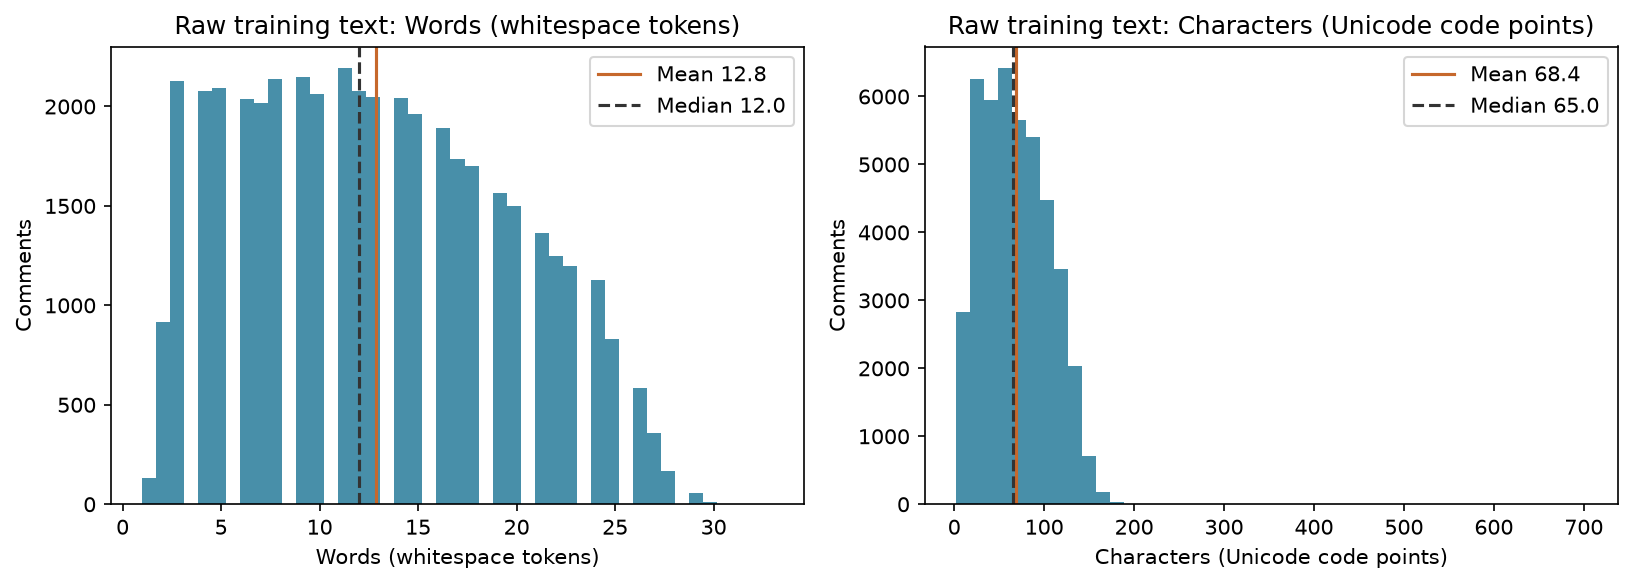

{'train_word_tokens': 557515, 'train_lexical_vocabulary': 26939, 'content_vocabulary': 26649, 'stopword_token_fraction': 0.49492659390330307, 'iqr_upper_word_threshold': 34.5, 'long_comment_flags': 0, 'max_label_prevalence_drift_pp': 0.7235835750517554}


,id,text,labels,word_count


In [14]:
display(pd.read_csv('reports/tables/length_statistics.csv'))
display(Image(filename='reports/figures/text_lengths.png'))
print(eda['content_summary'])
display(pd.read_csv('reports/tables/long_comment_review.csv').head(5))


## 5. Label imbalance and multi-label relationships
Per-label prevalence divides positive comments by the split size, so percentages can sum above 100%. Cardinality counts labels per comment; density divides cardinality by 28. Co-occurrence uses int64 arithmetic to avoid overflow. Jaccard normalizes for support.

Later classifiers should use multi-label outputs and micro/macro/per-label F1. Class weighting, resampling, and thresholds are experiment choices; fit or select them using training/validation only.

,train,validation,test
admiration,4130,488,504
amusement,2328,303,264
anger,1567,195,198
annoyance,2470,303,320
approval,2939,397,351
caring,1087,153,135
confusion,1368,152,153
curiosity,2191,248,284
desire,641,77,83
disappointment,1269,163,151


{'multi_label_ratio': 0.16360285648468095, 'label_cardinality': 1.1772172310527529, 'label_density': 0.04204347253759832}


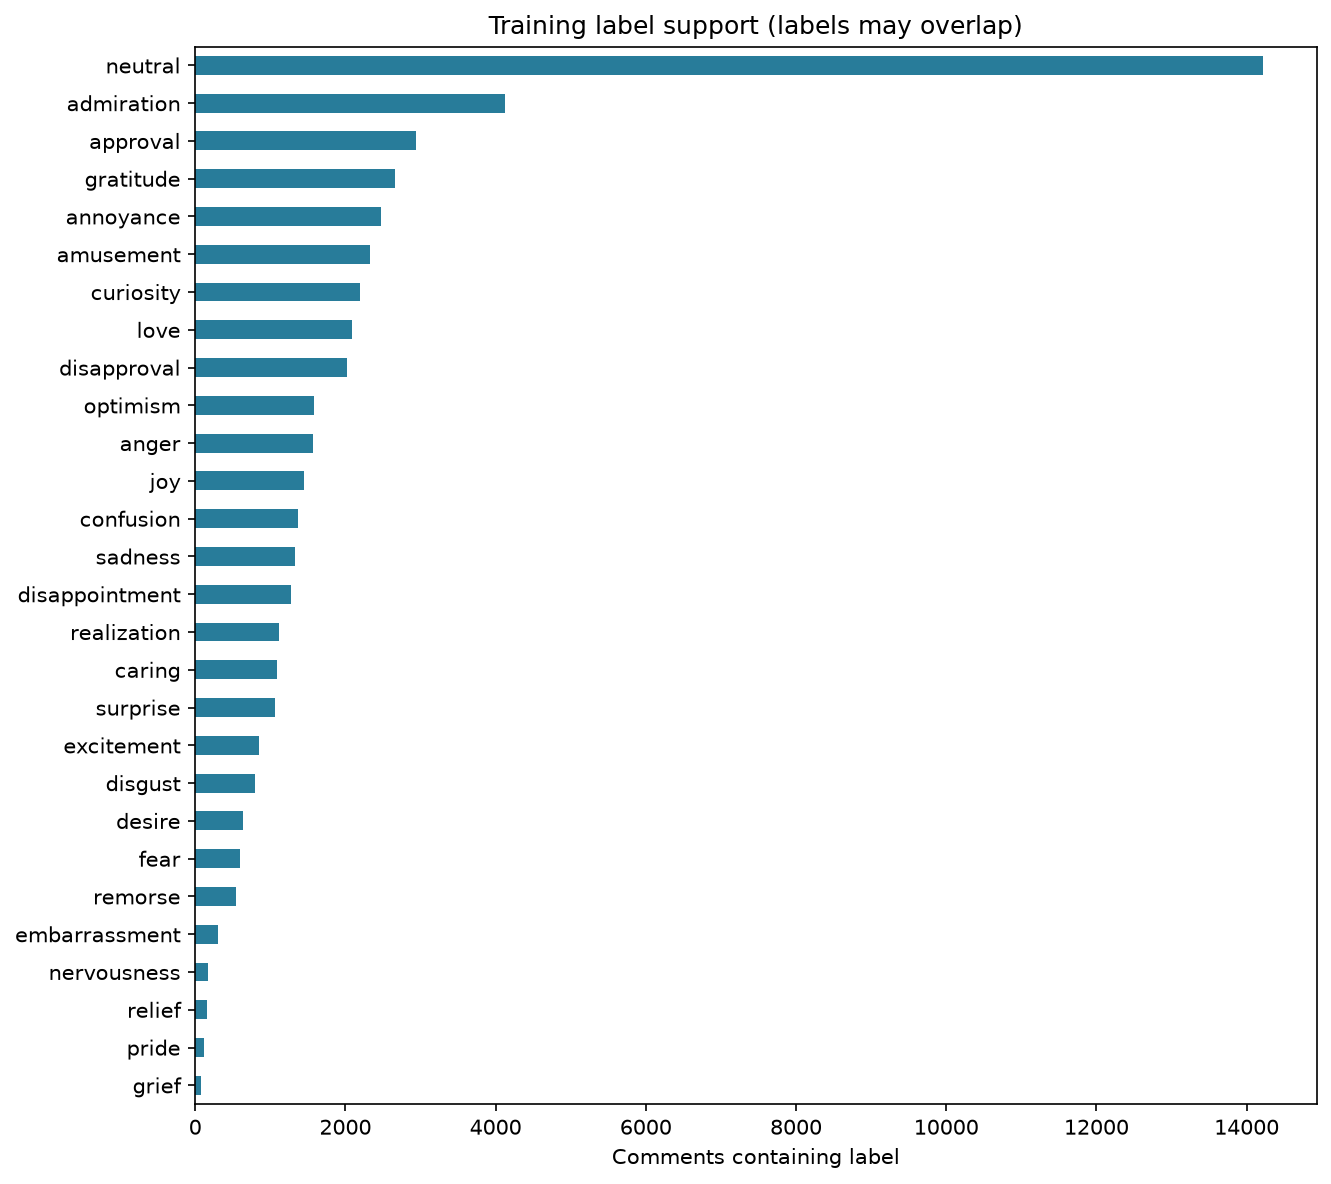

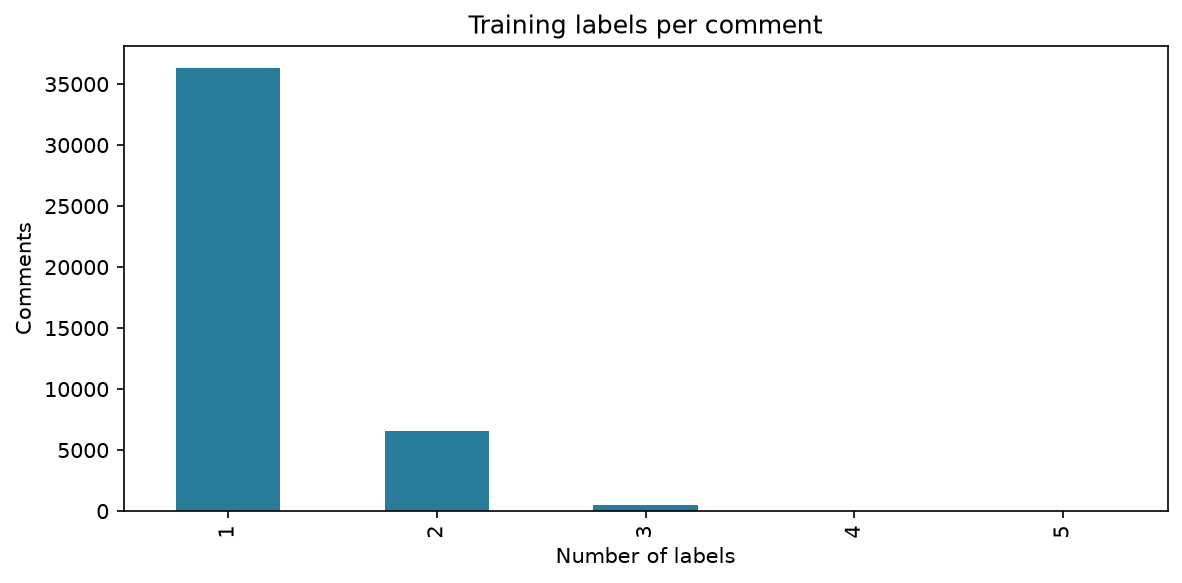

,emotion_a,emotion_b,count,jaccard
0,admiration,gratitude,279,0.042837
1,anger,annoyance,269,0.071391
2,admiration,approval,246,0.036055
3,confusion,curiosity,212,0.063340
4,approval,neutral,202,0.011913
5,admiration,love,192,0.031873
6,annoyance,disapproval,178,0.041261
7,disappointment,sadness,133,0.054021
8,annoyance,neutral,132,0.007972
9,admiration,joy,126,0.023094


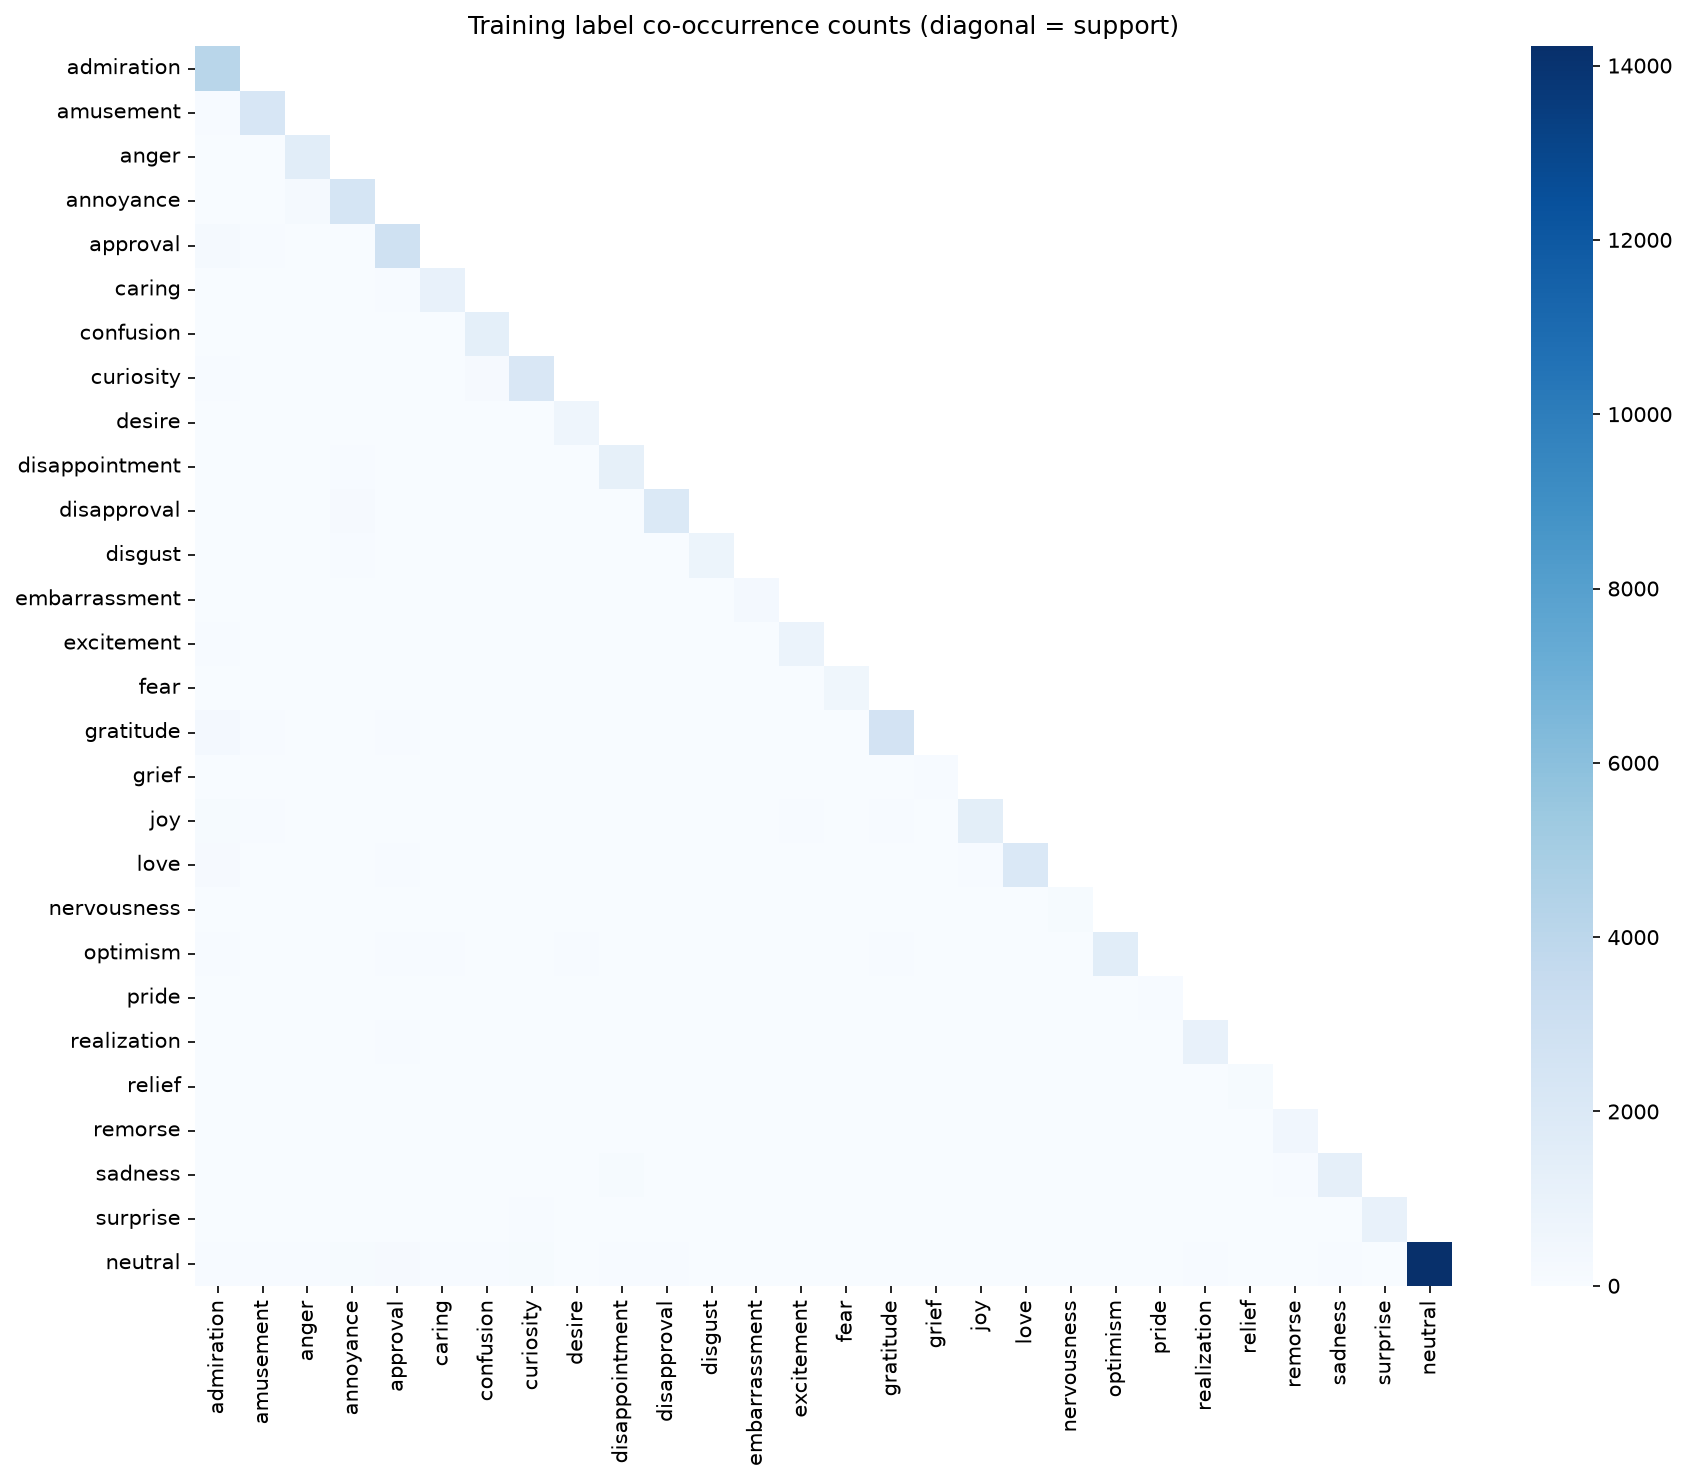

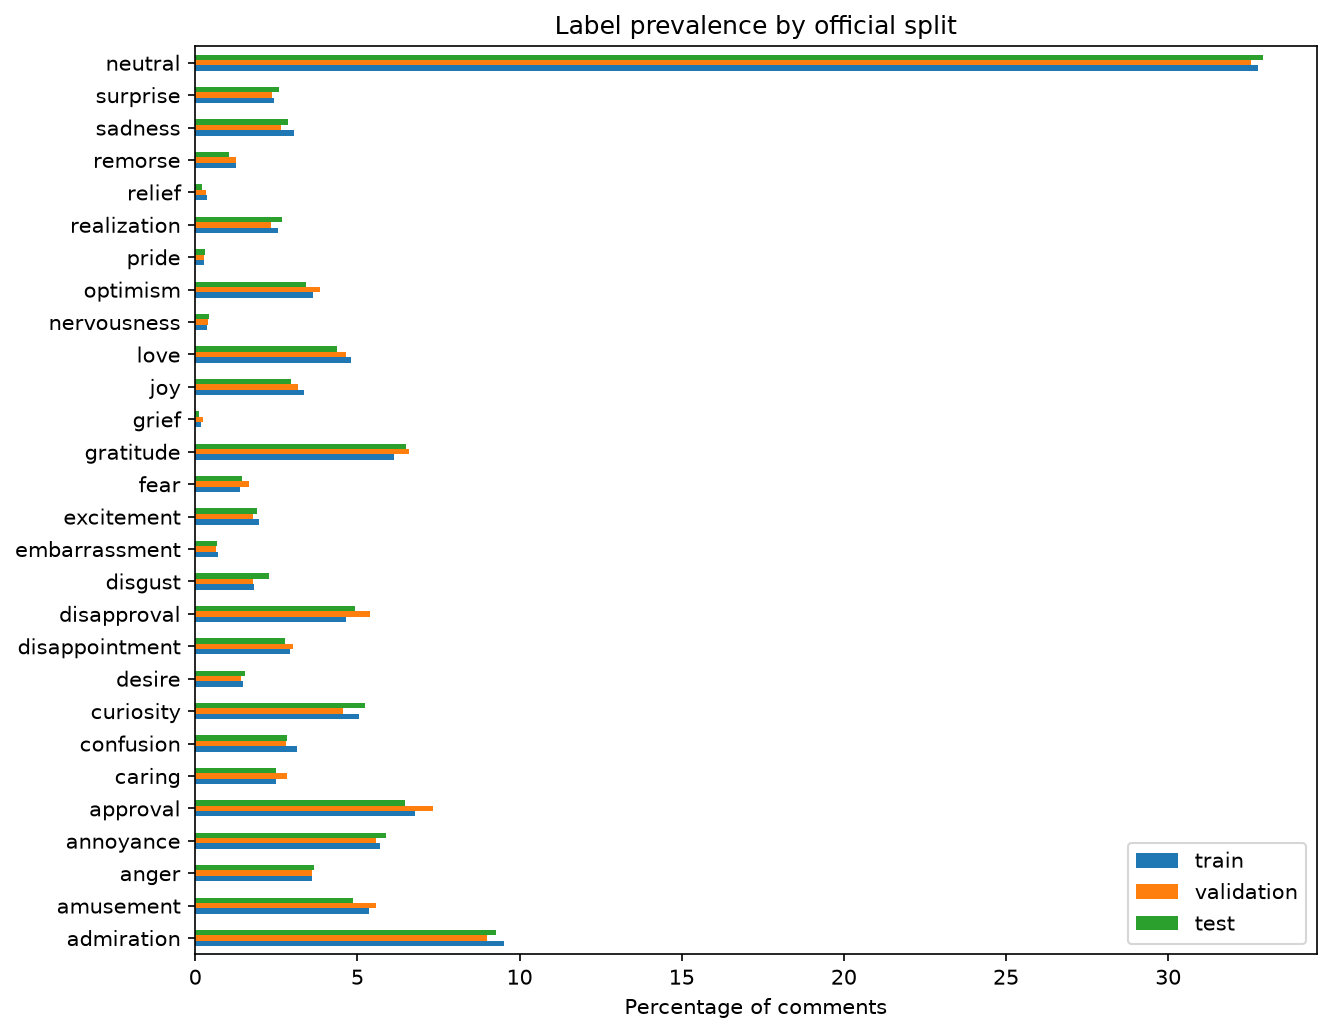

In [15]:
display(eda['supports'])
stats = eda['statistics']['train']
print({k: stats[k] for k in ('multi_label_ratio','label_cardinality','label_density')})
display(Image(filename='reports/figures/label_support.png'))
display(Image(filename='reports/figures/label_cardinality.png'))
display(pd.read_csv('reports/tables/emotion_pairs.csv').head(12))
display(Image(filename='reports/figures/cooccurrence.png'))
display(Image(filename='reports/figures/split_prevalence.png'))


## 6. Word frequencies, stopwords, vocabulary and class keywords
Regex lexical tokens keep apostrophes; punctuation/emoji are tracked separately. Keyword-only filtering excludes common stopwords and entity masks, but protects negation and intensifiers. Bigrams are formed before filtering to preserve adjacency. Model inputs preserve mask tokens.

A multi-label comment contributes to each of its label categories. Vocabulary type-token ratio varies with corpus size. Mean class TF-IDF and centroid similarity describe lexical overlap, not classifier accuracy or mean pairwise document similarity.

,term,count
0,the,18003
1,i,16237
2,to,12600
3,a,12356
4,you,9901
5,and,9036
6,is,8472
7,that,8007
8,name,7905
9,it,7759


,term,count
0,the,18003
1,i,16237
2,to,12600
3,a,12356
4,you,9901
5,and,9036
6,is,8472
7,that,8007
8,name,7905
9,it,7759


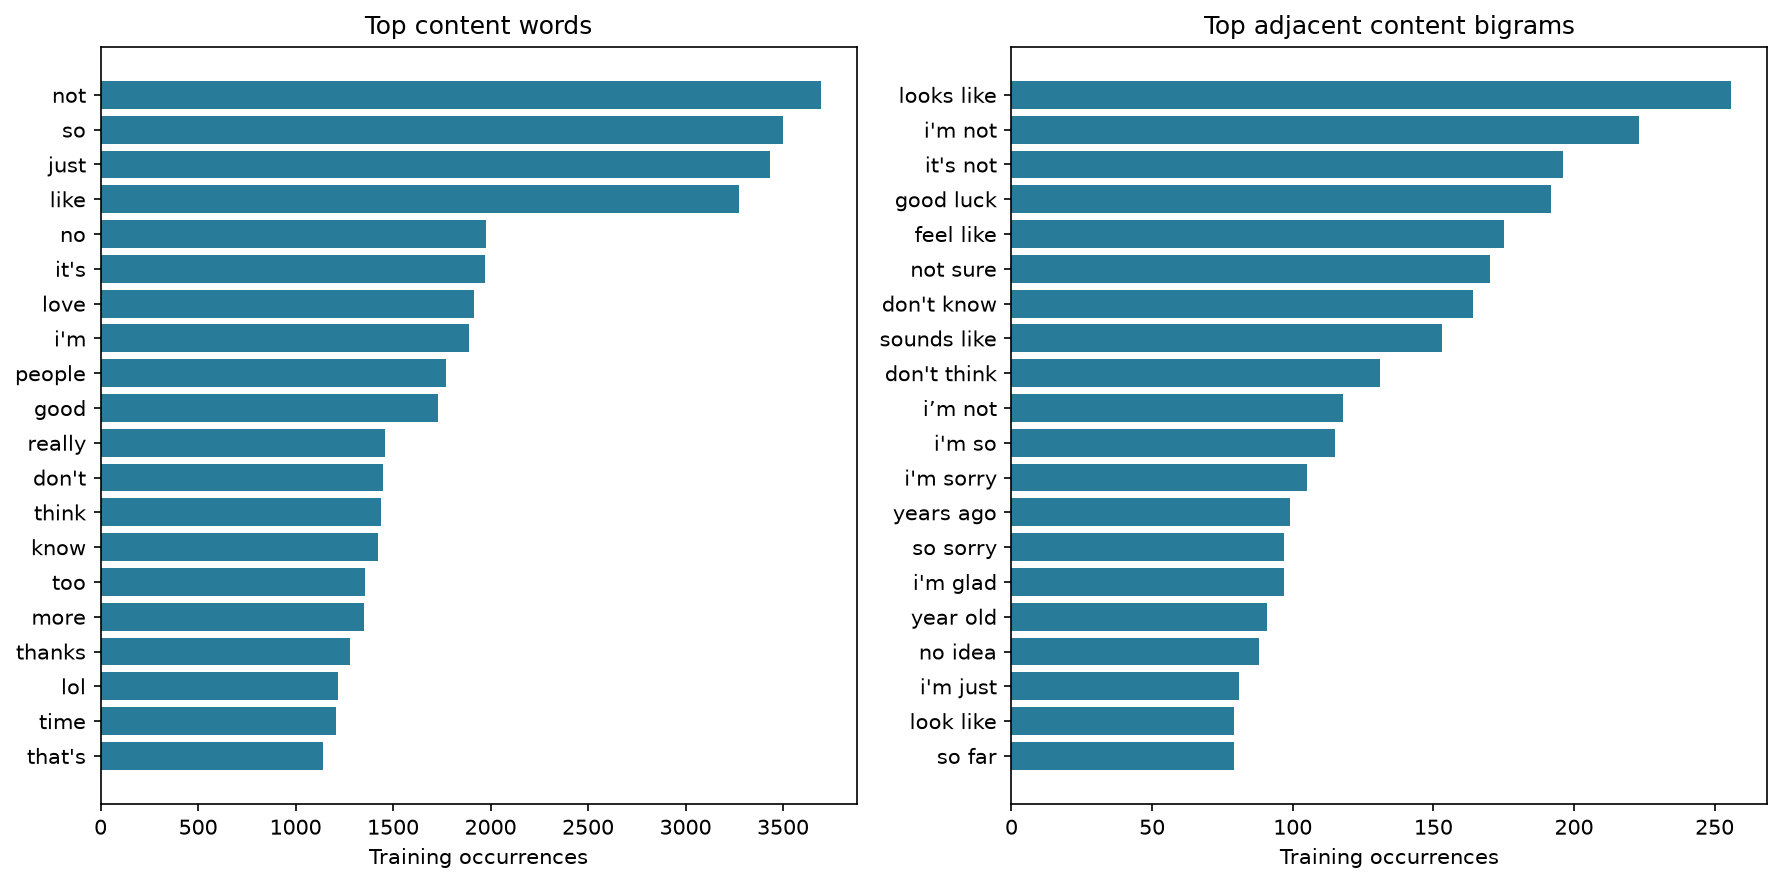

,cue,comments,percent
0,url,0,0.000000
1,user_mention,66,0.152039
2,masked_entity,6134,14.130385
3,negation,11100,25.570145
4,exclamation,6022,13.872380
5,question,4581,10.552868
6,non_ascii,6390,14.720111


,emotion,comments,content_tokens,unique_tokens,type_token_ratio,mean_raw_words
0,admiration,4130,25968,6226,0.239757,11.913317
1,amusement,2328,15796,4465,0.282666,12.662371
2,anger,1567,9633,3576,0.371224,11.971283
3,annoyance,2470,17806,5399,0.303212,13.964372
4,approval,2939,20324,5778,0.284294,13.697856
5,caring,1087,7422,2484,0.334681,14.108556
6,confusion,1368,9468,3439,0.363223,14.409357
7,curiosity,2191,13637,4747,0.348097,13.316750
8,desire,641,4428,1996,0.450768,14.622465
9,disappointment,1269,9295,3350,0.360409,14.449173


,emotion,term,count
0,admiration,good,632
1,admiration,great,578
2,admiration,so,450
3,admiration,like,322
4,admiration,awesome,263
...,...,...,...
1350,neutral,not,1313
1351,neutral,just,1166
1352,neutral,like,991
1353,neutral,so,793


,emotion,term,mean_tfidf
0,admiration,great,0.048265
1,admiration,good,0.046430
2,admiration,awesome,0.028496
3,admiration,amazing,0.025876
4,admiration,so,0.025146
...,...,...,...
405,neutral,not,0.019653
406,neutral,just,0.016965
407,neutral,like,0.015703
408,neutral,no,0.012858


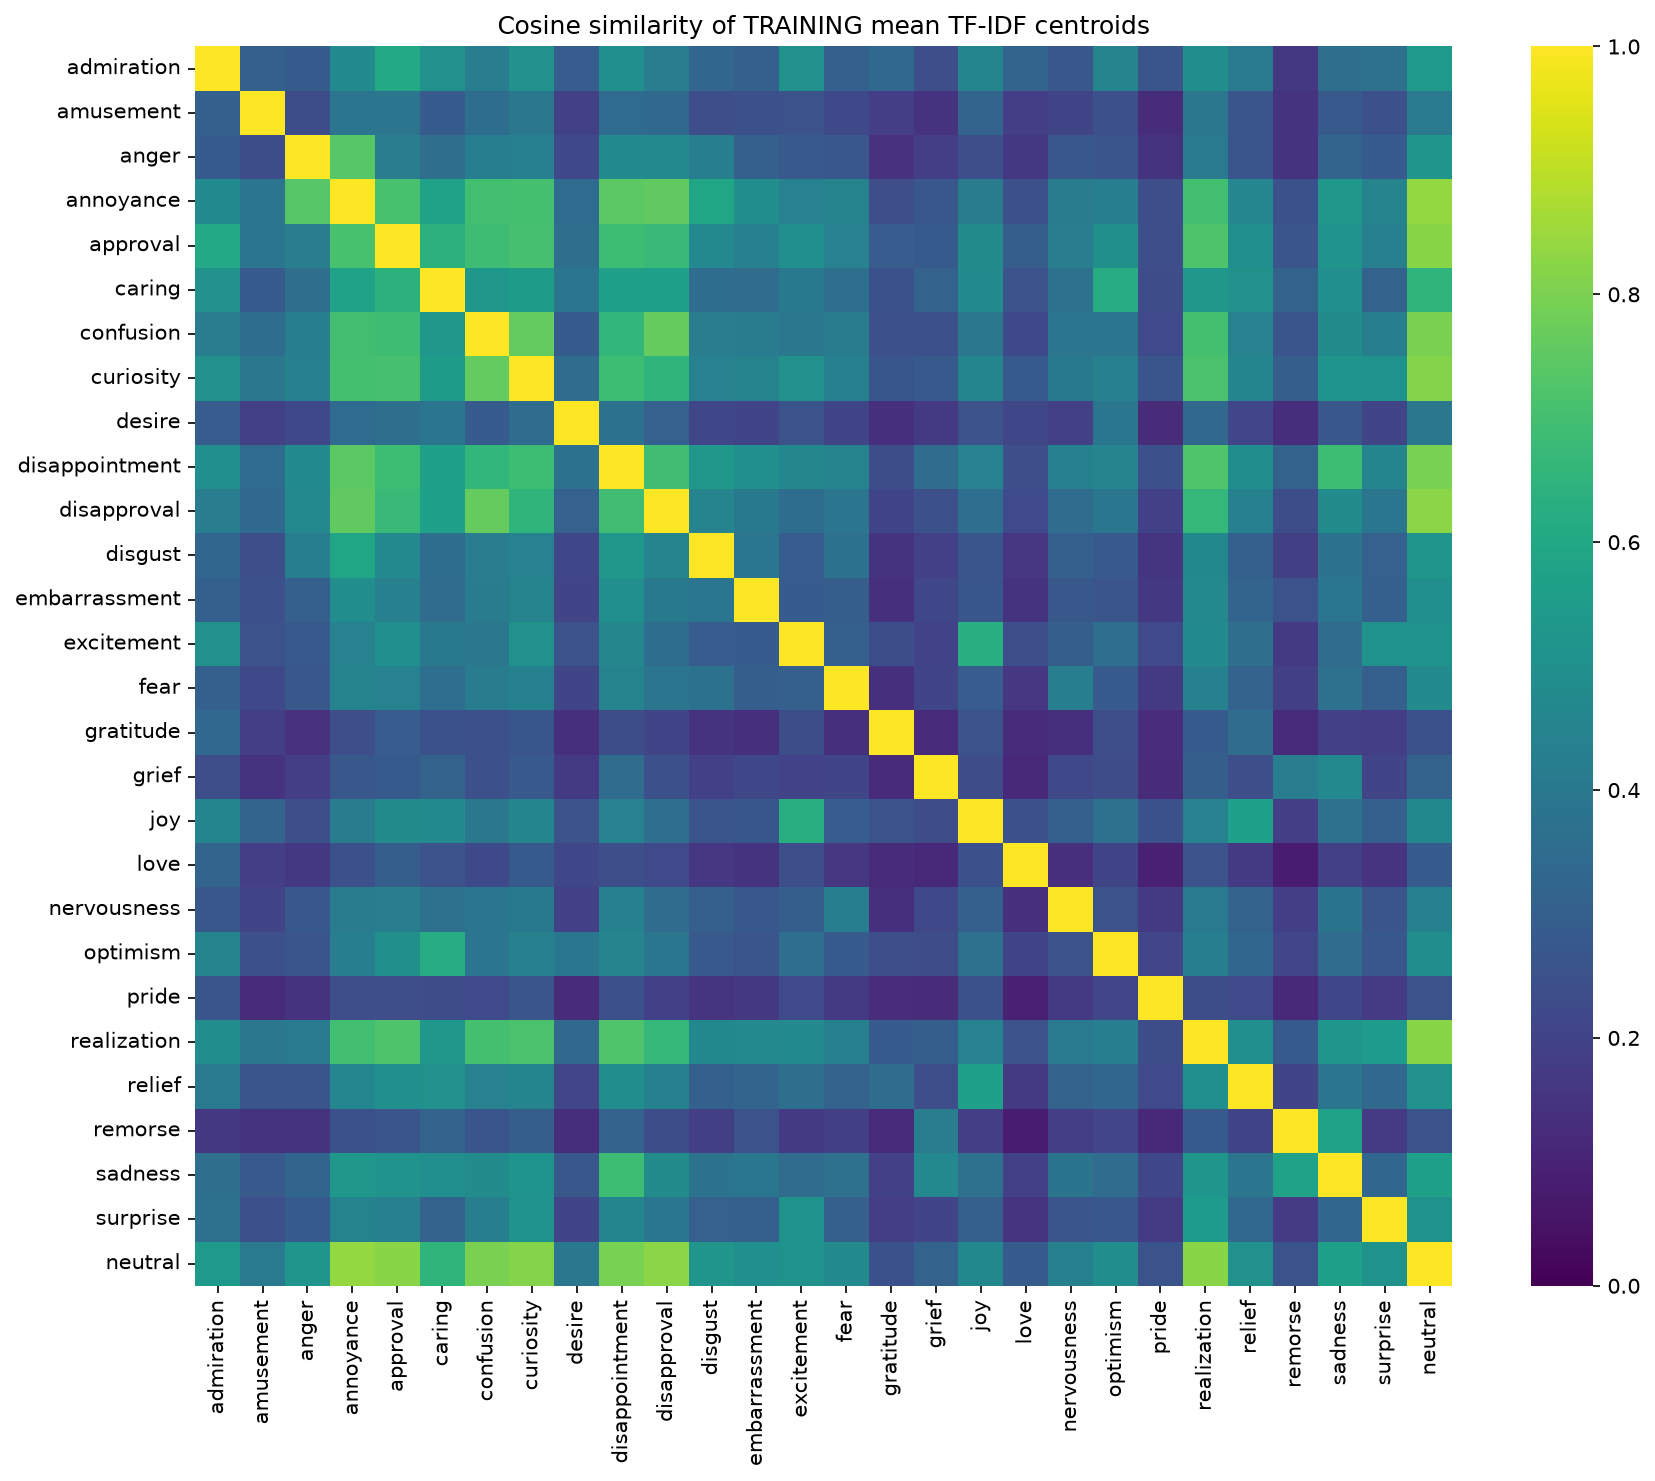

,emotion,id,text,labels
0,admiration,ed8wbdn,Damn youtube and outrage drama is super lucrative for reddit,[0]
1,admiration,ednhqdr,Famous for his 3-4 Defense,[0]
2,amusement,edex4ki,"Aww... she'll probably come around eventually, I'm sure she was just jealous of [NAME]... I mean, what wom...","[1, 4]"
3,amusement,ed7nnui,LOL. Super cute!,"[0, 1]"
4,anger,eezlygj,WHY THE FUCK IS BAYLESS ISOING,[2]
5,anger,edk0z9k,Fucking coward.,[2]
6,annoyance,ed0bdzj,Dirty Southern Wankers,[3]
7,annoyance,efdqav7,"[NAME] - same fucking problem, slightly better command of the English language.",[3]
8,approval,edex4ki,"Aww... she'll probably come around eventually, I'm sure she was just jealous of [NAME]... I mean, what wom...","[1, 4]"
9,approval,eek294p,You can always kneel.,[4]


In [16]:
display(pd.read_csv('reports/tables/raw_word_frequencies.csv').head(15))
display(pd.read_csv('reports/tables/stopword_frequencies.csv').head(15))
display(Image(filename='reports/figures/word_frequencies.png'))
display(pd.read_csv('reports/tables/text_cues.csv'))
display(pd.read_csv('reports/tables/vocabulary_by_emotion.csv'))
keywords = pd.read_csv('reports/tables/top_words_by_emotion.csv')
display(keywords.groupby('emotion', sort=False).head(5))
tfidf_terms = pd.read_csv('reports/tables/top_tfidf_by_emotion.csv')
display(tfidf_terms.groupby('emotion', sort=False).head(5))
display(Image(filename='reports/figures/centroid_similarity.png'))
display(pd.read_csv('reports/tables/samples_by_emotion.csv').head(12))


## 7. Configurable preprocessing and impact comparison
Default: Unicode/HTML normalization, URL and user placeholders, lowercasing and whitespace normalization. Punctuation, emoji, apostrophes, numbers and negation stay intact. Every transformation writes `processed_text` while retaining `text`, IDs, label lists and targets.

Stopword removal, punctuation removal, stemming, noun-only lemmatization, tokenization method and minimum word length are configurable. Stemming/lemmatization are mutually exclusive. Optional WordNet preparation happens automatically only when requested. Empty transformations use `EMPTYTOKEN`, preserving row alignment.

The comparison below measures data impact, not predictive performance.

In [17]:
comparison = compare_preprocessing(df_train)
comparison.to_csv('reports/tables/preprocessing_comparison.csv', index=False)
display(comparison)
examples = ["I'm NOT happy!!! 😢", "Thank you SO much ❤️", "Don't stop believing!", "See https://example.org u/friend &amp; [NAME]", "the"]
profiles = {'default': PreprocessingConfig(),
            'stopwords': PreprocessingConfig(remove_stopwords=True),
            'punctuation': PreprocessingConfig(remove_punctuation=True)}
display(pd.DataFrame([{'raw': t, **{name: preprocess_text(t, cfg) for name, cfg in profiles.items()}} for t in examples]))


,profile,mean_tokens,vocabulary,changed_comments,empty_fallback_rows
0,emotion_preserving,14.964778,27241,41503,0
1,stopwords_ablation,8.785902,26953,43325,16
2,punctuation_ablation,12.945543,27199,42689,2
3,embedding_minimal,14.968579,34048,2732,0


,raw,default,stopwords,punctuation
0,I'm NOT happy!!! 😢,i'm not happy!!! 😢,i'm not happy ! ! ! 😢,i'm not happy 😢
1,Thank you SO much ❤️,thank you so much ❤️,thank so ❤ ️,thank you so much ❤️
2,Don't stop believing!,don't stop believing!,don't stop believing !,don't stop believing
3,See https://example.org u/friend &amp; [NAME],see urltoken usertoken & [name],urltoken usertoken & [name],see urltoken usertoken name
4,the,the,EMPTYTOKEN,the


## 8. Preprocessed data export
Export original text, processed text, readable tokens, IDs and multi-hot targets without custom numeric token IDs or padding. Preprocessing does not truncate comments.

TF-IDF/BoW teammates fit their vectorizer on training processed_text, then transform validation/test. Pretrained-model teammates use the model tokenizer on original/minimally normalized text, including configurable padding/truncation. Padding remains a full-assignment requirement to implement in the downstream model pipeline.

In [18]:
CONFIG = PreprocessingConfig()
processed, impact, metadata = prepare_splits(splits, CONFIG)
impact.to_csv('reports/tables/preprocessing_impact.csv', index=False)
display(impact)
display(processed['train'][['id','text','processed_text','tokens','labels']].head(8))

# Verify exported records and targets still refer to the same comments.
for name, df in processed.items():
    reloaded = pd.read_json(f'data/processed/{name}.jsonl', lines=True)
    y = np.load(f'features/{name}_labels.npy', allow_pickle=False)
    assert reloaded['id'].tolist() == df['id'].tolist()
    assert reloaded['text'].tolist() == df['text'].tolist()
    assert reloaded['tokens'].tolist() == df['tokens'].tolist()
    np.testing.assert_array_equal(y, df[LABEL_NAMES].to_numpy())
print('Processed text and labels are row-aligned and validated.')


,split,rows,mean_tokens,empty_fallback_rows
0,train,43410,14.964778,0
1,validation,5426,14.906192,0
2,test,5427,14.830109,0


,id,text,processed_text,tokens,labels
0,eebbqej,My favourite food is anything I didn't have to cook myself.,my favourite food is anything i didn't have to cook myself.,"[my, favourite, food, is, anything, i, didn't, have, to, cook, myself, .]",[27]
1,ed00q6i,"Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actuall...","now if he does off himself, everyone will think hes having a laugh screwing with people instead of actuall...","[now, if, he, does, off, himself, ,, everyone, will, think, hes, having, a, laugh, screwing, with, people,...",[27]
2,eezlygj,WHY THE FUCK IS BAYLESS ISOING,why the fuck is bayless isoing,"[why, the, fuck, is, bayless, isoing]",[2]
3,ed7ypvh,To make her feel threatened,to make her feel threatened,"[to, make, her, feel, threatened]",[14]
4,ed0bdzj,Dirty Southern Wankers,dirty southern wankers,"[dirty, southern, wankers]",[3]
5,edvnz26,OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe PlAyOfFs! Dumbass Broncos fans circa December 2015.,omg peyton isn't good enough to help us in the playoffs! dumbass broncos fans circa december 2015.,"[omg, peyton, isn't, good, enough, to, help, us, in, the, playoffs, !, dumbass, broncos, fans, circa, dece...",[26]
6,ee3b6wu,Yes I heard abt the f bombs! That has to be why. Thanks for your reply:) until then hubby and I will anxio...,yes i heard abt the f bombs! that has to be why. thanks for your reply:) until then hubby and i will anxio...,"[yes, i, heard, abt, the, f, bombs, !, that, has, to, be, why, ., thanks, for, your, reply, :, ), until, t...",[15]
7,ef4qmod,We need more boards and to create a bit more space for [NAME]. Then we’ll be good.,we need more boards and to create a bit more space for [name]. then we’ll be good.,"[we, need, more, boards, and, to, create, a, bit, more, space, for, [name], ., then, we’ll, be, good, .]","[8, 20]"


Processed text and labels are row-aligned and validated.
